# Directed Evolution loop — V1

First simple test of `sequence_classesV1.py` (`Protocol`, `Lambda`) and `analysisV1.py`
(the 8 plotting/analysis functions), on a small toy library.

Pipeline for one round of `Protocol.loop_DE()`:

$$
\lambda_0 \xrightarrow{\text{NGS}} \lambda_0' \qquad
\lambda_0 \xrightarrow{\text{sampling}} \lambda_1 \xrightarrow{\text{produce\_capsids}} \lambda_2 \xrightarrow{\text{NGS}} \lambda_2' \qquad
\lambda_2 \xrightarrow{\text{selectivty}} \lambda_3 \xrightarrow{\text{NGS}} \lambda_3' \qquad
\lambda_3 \xrightarrow{\text{bacterial\_amplification}} \lambda_4
$$

`lambda0/1/2/3/4` = true pools (biological chain). `lambda0p/2p/3p` = NGS read-count
snapshots (side channel, Negative Binomial, never fed back into the chain).


## 0. Protocol parameters

Fixed constants from `sequence_classesV1.py`, used as defaults throughout `Protocol` unless overridden at construction time.

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# GB10 has unified CPU/GPU memory: JAX's default (preallocate ~75% of
# total platform memory on first use) leaves too little headroom for the
# large NumPy Potts feature matrices built later in this notebook and can
# OOM-kill the kernel. Must run before the first `import jax` anywhere
# (including transitively via sequence_classesV1 / RegressionV1), hence
# this cell has to stay first.

In [2]:
import sequence_classesV1
print(sequence_classesV1.__file__)
print(sequence_classesV1.message)

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/sequence_classesV1.py
file 2.1


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import analysisV1
print(analysisV1.__file__)
print(analysisV1.message)

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V1/analysisV1.py
file analysis 2.3


In [4]:
import RegressionV1 as reg
print(reg.message)

file regression 1.4


In [5]:
import pandas as pd
from sequence_classesV1 import rho, alpha, epsilon, T_sel, T_viab, M, K_MM, K_MM_amp, D, N1, phi

params = pd.DataFrame([
    ("rho",     rho,     "HEK cells transfected per plasmid"),
    ("alpha",   alpha,   "capsid yield per transfected cell"),
    ("epsilon", epsilon, "per-cell production noise amplitude"),
    ("T_sel",   T_sel,   "selectivity temperature"),
    ("T_viab",  T_viab,  "viability temperature (larger = more uniform production)"),
    ("M",       M,       "number of PCR amplification cycles"),
    ("K_MM",    K_MM,    "Michaelis-Menten saturation constant for PCR"),
    ("K_MM_amp",K_MM_amp,"same as before"),
    ("D",       D,       "sequencing depth (reads per NGS readout)"),
    ("N1",      N1,      "number of plasmids sampled for transfection"),
    ("phi",     phi,     "NB dispersion for sequencing reads (smaller phi = closer to Poisson)"),
], columns=["Parameter", "Value", "Description"])

params

,Parameter,Value,Description
0,rho,1.000000e-03,HEK cells transfected per plasmid
1,alpha,4.000000e+03,capsid yield per transfected cell
2,epsilon,1.000000e-02,per-cell production noise amplitude
3,T_sel,5.000000e-01,selectivity temperature
4,T_viab,5.000000e-01,viability temperature (larger = more uniform p...
5,M,4.000000e+01,number of PCR amplification cycles
6,K_MM,1.000000e+06,Michaelis-Menten saturation constant for PCR
7,K_MM_amp,1.000000e+08,same as before
8,D,1.000000e+10,sequencing depth (reads per NGS readout)
9,N1,1.000000e+07,number of plasmids sampled for transfection


In [6]:
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]

pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

## 1. Imports

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from sequence_classesV1 import *
from analysisV1 import *

## 2. Toy library and ground-truth (Teacher) Potts model

Small library so the whole notebook runs in seconds. `F_viab`/`F_sel` are dense
random profile matrices; `J_viab`/`J_sel` are *sparse* (only a handful of nonzero
pairwise couplings each) — a dense random `J` blows up `exp(score/T)` in
`produce_capsids` since it sums scores over every transfected cell.

In [8]:
key = jax.random.key(0)
key, k_seq, k_Fv, k_Fs, k_Jv, k_Js = jax.random.split(key, 6)

num_sequences   = 800000
L               = 7     # sequence length
A               = 20    # amino-acid alphabet size

sequences = jax.random.randint(k_seq, shape=(num_sequences, L), minval=0, maxval=A)

F_viab, F_sel, J_viab, J_sel  = initialize_random_weights(key=key)

print(f"Library: {num_sequences} sequences of length {L}")
print(f"F_viab shape: {F_viab.shape}, J_viab nonzero entries: {int(jnp.sum(J_viab != 0))}")

Library: 800000 sequences of length 7
F_viab shape: (20, 7), J_viab nonzero entries: 16800


Sanity check with `plot_teacher_weights` (function 1 from `analysisV1.py`):

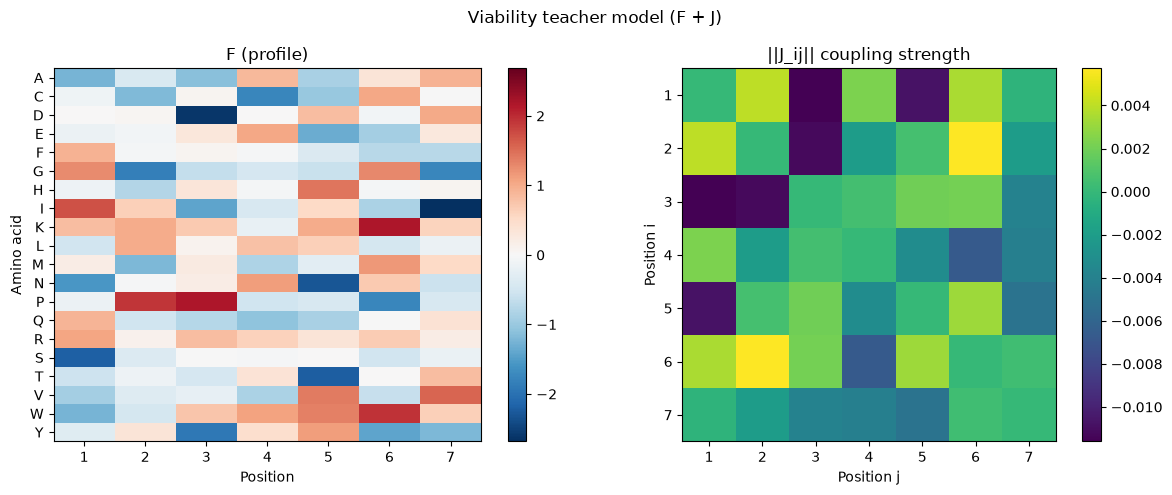

In [18]:
_ = plot_teacher_weights(F_viab, J_viab, title="Viability teacher model (F + J)")
plt.show()

## 3. Build the `Protocol`

`Protocol` wraps the whole simulation: `sequence` (identity, `(d0, 7)`, constant) and
`lambda0..lambda4` / `lambda0p,2p,3p` (abundance pools, all `(d0,)`, evolve each round).

In [ ]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Initial library, colored by viability/selectivity score (function 2):

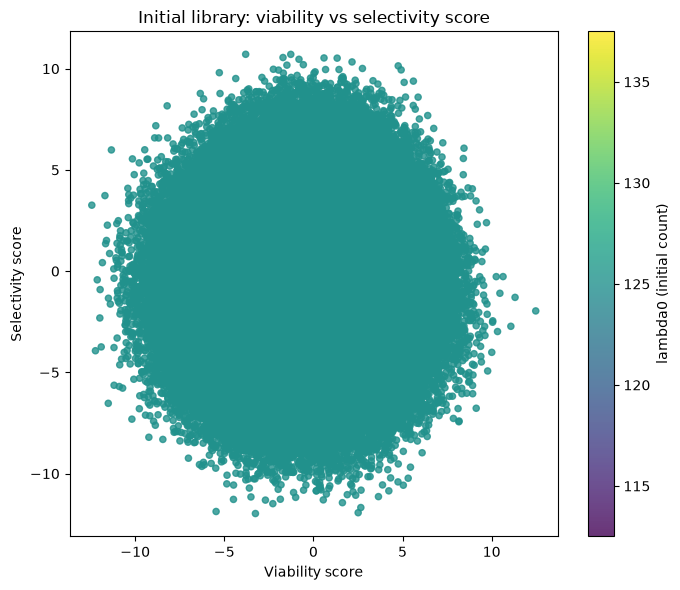

In [ ]:
_ = plot_initial_library_scores(protocol)
plt.show()

## 4. Run one round of `loop_DE()`

In [ ]:
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,137  non-zero=799997 / 800000
  lambda2    total=123,522,105,344  non-zero=9145 / 800000
  lambda3    total=43,054,669,824  non-zero=7981 / 800000
  lambda4    total=   100,001,952  non-zero=4731 / 800000
  lambda0p   total= 9,995,730,169  non-zero=799999 / 800000
  lambda2p   total= 9,684,607,723  non-zero=8119 / 800000
  lambda3p   total= 9,410,867,857  non-zero=6875 / 800000


Counts through viability + selectivity (function 3):

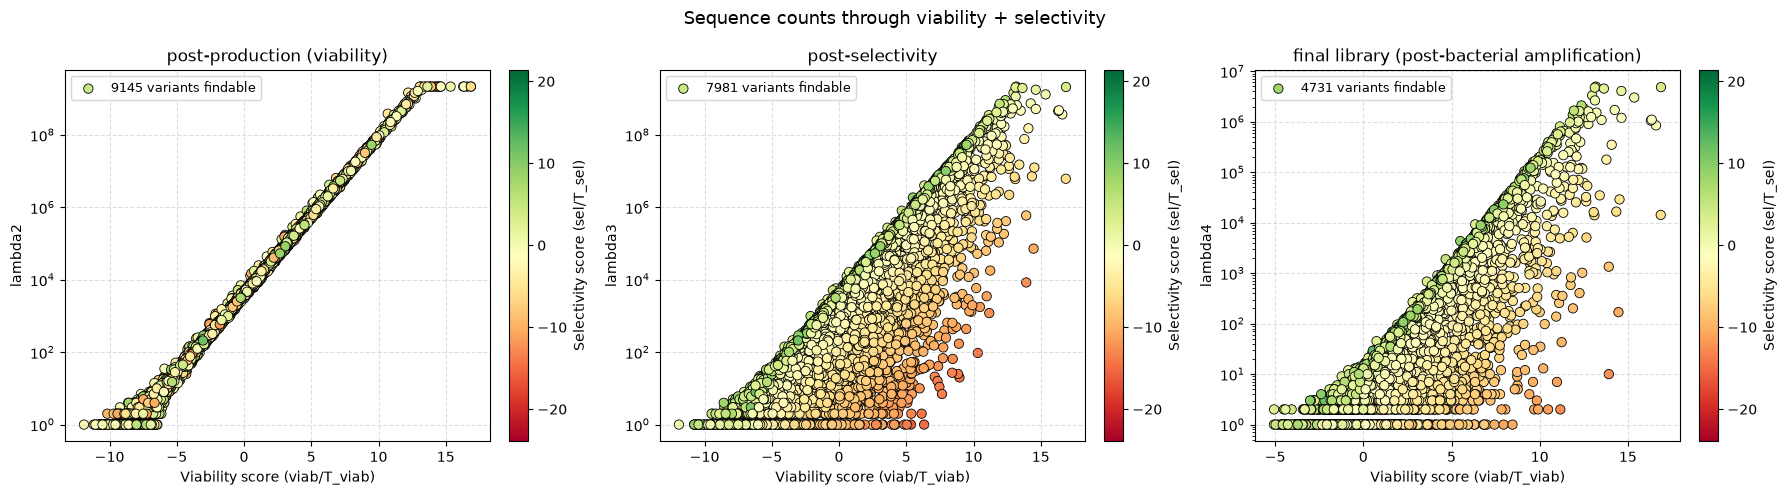

In [ ]:
_ = plot_counts_after_selection(protocol)
plt.show()

All 8 lambdas of that same round on one plot (function 8):

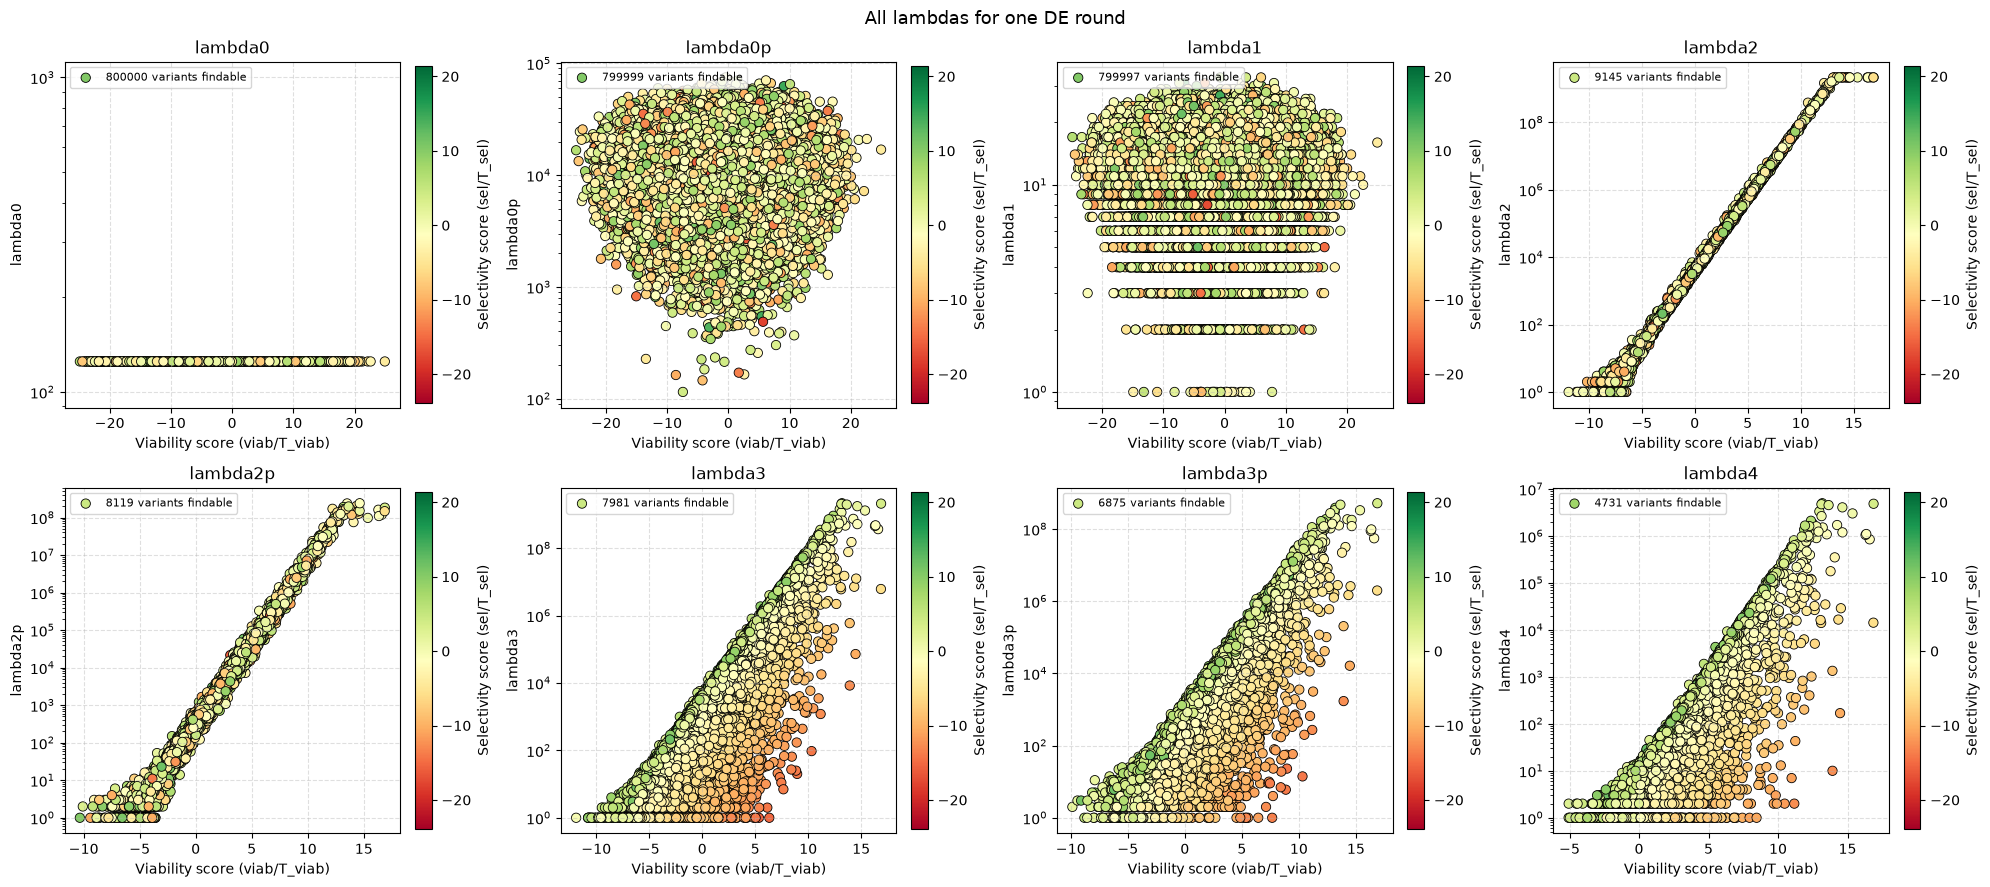

In [ ]:
_ = plot_loop_lambdas(protocol, run_loop=False)  # reuse the round we just ran
plt.show()

## 5. Run several rounds with `N_loop_DE` and track library evolution

In [ ]:
"""protocol_multi = ProtocolV2(
    N0=100_000_000, N1=10_000_000, sequences=sequences, 
    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, 
    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,
)

fig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)
plt.show()

print(f"N_loop_DE returned {len(rounds)} rounds")"""

'protocol_multi = ProtocolV2(\n    N0=100_000_000, N1=10_000_000, sequences=sequences, \n    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, \n    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,\n)\n\nfig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)\nplt.show()\n\nprint(f"N_loop_DE returned {len(rounds)} rounds")'

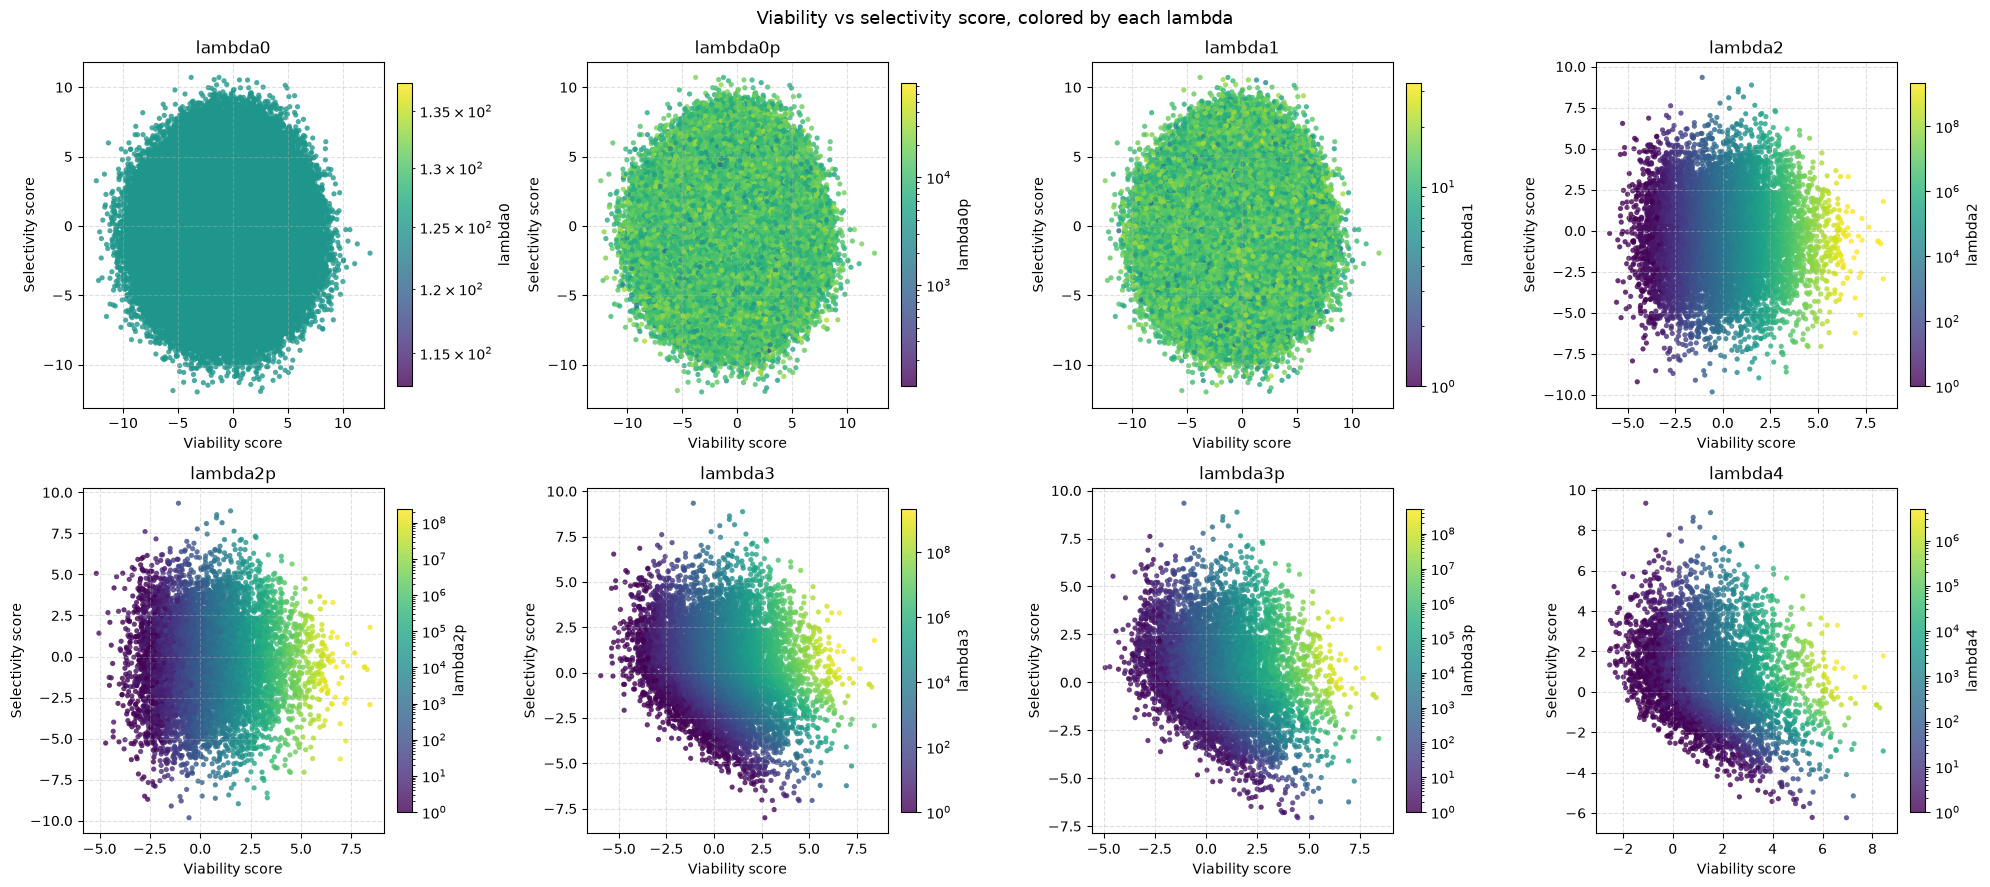

In [ ]:
_ = plot_all_lambda_scores(protocol)
plt.show()

## Test 1 : Value of F, the factor of dilution

Whatever the value of D, a large part of sequences disappear in the NGS. Lets see how many sequences we have over some threshold.

In [ ]:
threshold_values = [10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
lambdas          = [lambda0, lambda1, lambda2, lambda3, lambda4]
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]

number_of_seq_threshold(lambdas=lambdas, thresholds=threshold_values, names=names)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0,800000,800000,0,0,0,0
lambda1,638634,0,0,0,0,0
lambda2,8249,6983,5431,3688,2174,1069
lambda3,6742,5363,3899,2447,1389,647
lambda4,2982,1720,846,337,123,29


In [ ]:
lambdaps         = [lambda0p, lambda2p, lambda3p]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]
number_of_seq_threshold(lambdas=lambdaps, thresholds=threshold_values, names=namesp)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0p,799999,799999,799737,479426,0,0
lambda2p,6828,5229,3504,1999,975,395
lambda3p,5863,4414,2931,1720,846,333


Relative proportions (`proportion_above_threshold` from `analysisV1.py`): how many sequences are abundant -- present above a given percentage of the pool total -- for the biological chain and the NGS reads separately.

In [ ]:
pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,0,0,0,800000,800000,800000,800000,800000,800000,800000
lambda1,0,0,0,0,638634,799997,799997,799997,799997,799997,799997
lambda2,32,145,388,1003,2035,3541,5274,6853,8128,8895,9145
lambda3,29,123,337,844,1721,2942,4465,5858,7117,7981,7981
lambda4,29,123,337,846,1717,2921,4169,4731,4731,4731,4731


In [ ]:
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds_p, names=names)

,> 0.0001%,> 8e-05%,> 6e-05%,> 5.5e-05%,> 5e-05%,> 4.5e-05%,> 4e-05%,> 2e-05%,> 1e-05%
lambda,,,,,,,,,
lambda0,800000,800000,800000,800000,800000,800000,800000,800000,800000
lambda1,638634,744223,788131,788131,795799,795799,798772,799963,799997
lambda2,2035,2180,2346,2406,2462,2531,2591,3043,3541
lambda3,1721,1822,1968,2011,2054,2109,2177,2524,2942
lambda4,1717,1806,1962,2004,2053,2103,2181,2520,2921


In [ ]:
proportion_above_threshold(lambdas=lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,0,0,479643,799737,799999,799999,799999,799999,799999
lambda2p,33,147,398,989,2013,3519,5246,6828,8119,8119,8119
lambda3p,32,119,343,859,1745,2962,4453,5863,6875,6875,6875


The factor of dilution can help signicantly to get rid of variants that are not the optimal variants. The effect on noise should be analyse for further conclusion.

In [ ]:
protocol_dil1000 = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=1000, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol_dil1000.sequence shape:", protocol_dil1000.sequence.shape, "  (identity, never changes)")
print("protocol_dil1000.model     :", protocol_dil1000.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol_dil1000.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol_dil1000, name).shape}")

protocol_dil1000.sequence shape: (800000, 7)   (identity, never changes)
protocol_dil1000.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


In [ ]:
new_bio_row, new_ngs_row = protocol_dil1000.loop_DE()
new_lambda0, new_lambda1, new_lambda2, new_lambda3, new_lambda4 = new_bio_row
new_lambda0p, new_lambda2p, new_lambda3p = new_ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", new_lambda0), ("lambda1", new_lambda1), ("lambda2", new_lambda2),
                    ("lambda3", new_lambda3), ("lambda4", new_lambda4),
                    ("lambda0p", new_lambda0p), ("lambda2p", new_lambda2p), ("lambda3p", new_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol_dil1000.d0}")
    
new_lambdaps         = [new_lambda0p, new_lambda2p, new_lambda3p]

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,137  non-zero=799997 / 800000
  lambda2    total=123,522,105,344  non-zero=9145 / 800000
  lambda3    total=43,054,669,824  non-zero=7981 / 800000
  lambda4    total=   100,001,952  non-zero=4731 / 800000
  lambda0p   total=10,002,709,303  non-zero=94093 / 800000
  lambda2p   total= 9,684,503,874  non-zero=5810 / 800000
  lambda3p   total= 9,410,178,926  non-zero=4270 / 800000


In [ ]:
proportion_above_threshold(lambdas=new_lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,1,38841,89672,93812,94092,94093,94093,94093,94093
lambda2p,33,147,397,992,2023,3509,5204,5810,5810,5810,5810
lambda3p,32,119,342,858,1734,2984,4184,4270,4270,4270,4270


Visualizing which variants disappear as dilution increases: every variant found in `lambda3p` is plotted (x = viability score, y = selectivity score), once per `dilution_factor`, layered from red (weak dilution, most variants present) up to blue (strong dilution, drawn last/on top). A point that stays visibly red was lost once dilution increased; a point that ends up blue survived even the strongest dilution tested -- this lets us check directly whether attrition is uniform across score-space or concentrated on low-score (inefficient, lower-abundance) variants. Note the inclusion is only approximate (~97-99.8% overlap between consecutive levels), since each `dilution_factor` redraws independent randomness rather than sub-sampling the previous draw.

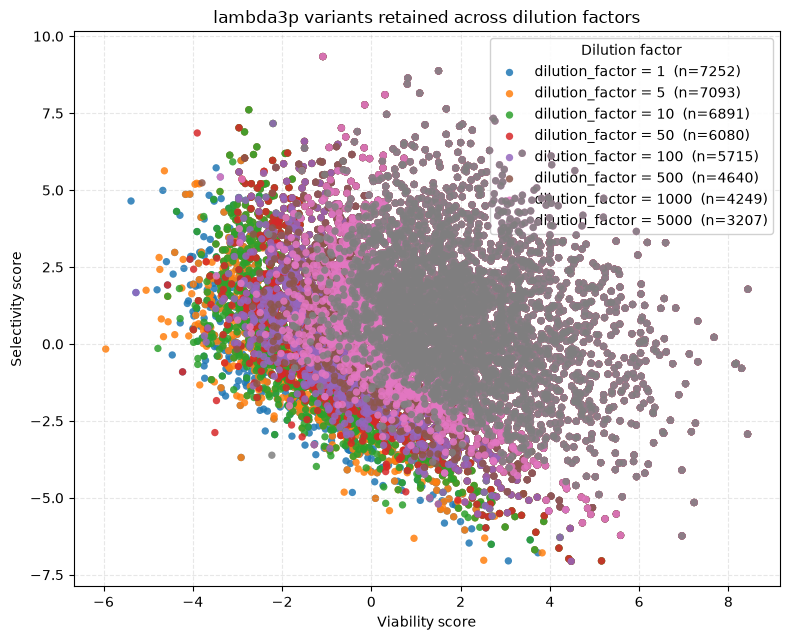

In [ ]:
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol_dil1000, dilution_factors_test)
plt.show()

### Let's add some noise to see how dilution affects the results.

protocol_noise4.sequence shape: (800000, 7)   (identity, never changes)
protocol_noise4.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

After loop_DE():
  lambda0_noise4 total=   100,000,000  non-zero=800000 / 800000
  lambda1_noise4 total=     9,998,137  non-zero=799997 / 800000
  lambda2_noise4 total=463,616,802,816  non-zero=8661 / 800000
  lambda3_noise4 total=207,584,264,192  non-zero=7594 / 800000
  lambda4_noise4 total=   100,001,160  non-zero=3882 / 800000
  lambda0p_noise4 total= 9,995,730,169  non-zero=799999 / 800000
  lambda2p_noise4 total=10,070,696,517  non-zero=7145 / 800000
  lambda3p_noise4 total= 9,859,504,097  non-zero=6177 / 800000


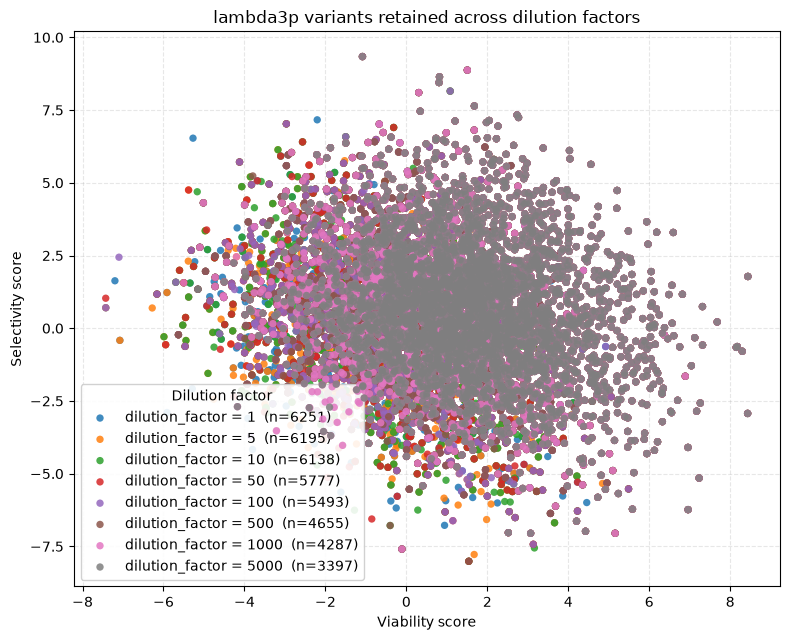

In [ ]:
protocol_noise4 = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol_noise4.sequence shape:", protocol_noise4.sequence.shape, "  (identity, never changes)")
print("protocol_noise4.model     :", protocol_noise4.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol_noise4.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol_noise4, name).shape}")
    
bio_row_noise4, ngs_row_noise4 = protocol_noise4.loop_DE()
lambda0_noise4, lambda1_noise4, lambda2_noise4, lambda3_noise4, lambda4_noise4 = bio_row_noise4
lambda0p_noise4, lambda2p_noise4, lambda3p_noise4 = ngs_row_noise4

print("After loop_DE():")
for label, arr in [("lambda0_noise4", lambda0_noise4), ("lambda1_noise4", lambda1_noise4), ("lambda2_noise4", lambda2_noise4),
                    ("lambda3_noise4", lambda3_noise4), ("lambda4_noise4", lambda4_noise4),
                    ("lambda0p_noise4", lambda0p_noise4), ("lambda2p_noise4", lambda2p_noise4), ("lambda3p_noise4", lambda3p_noise4)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol_noise4.d0}")
    
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol_noise4, dilution_factors_test)
plt.show()

### What happens after multiple rounds (with and without noise)

protocol_multi_lownoise.sequence shape: (800000, 7)   (identity, never changes)
protocol_multi_lownoise.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Directed evolution rounds: 100%|██████████| 3/3 [00:02<00:00,  1.07it/s]


  lambda0    total=   100,010,264  non-zero= 504 / 800000
  lambda1    total=    10,002,487  non-zero= 500 / 800000
  lambda2    total=305,362,337,792  non-zero= 277 / 800000
  lambda3    total=197,563,564,032  non-zero= 277 / 800000
  lambda4    total=    99,998,736  non-zero= 277 / 800000
  lambda0p   total= 9,440,110,015  non-zero= 500 / 800000
  lambda2p   total=10,293,916,687  non-zero= 277 / 800000
  lambda3p   total= 9,909,391,770  non-zero= 277 / 800000


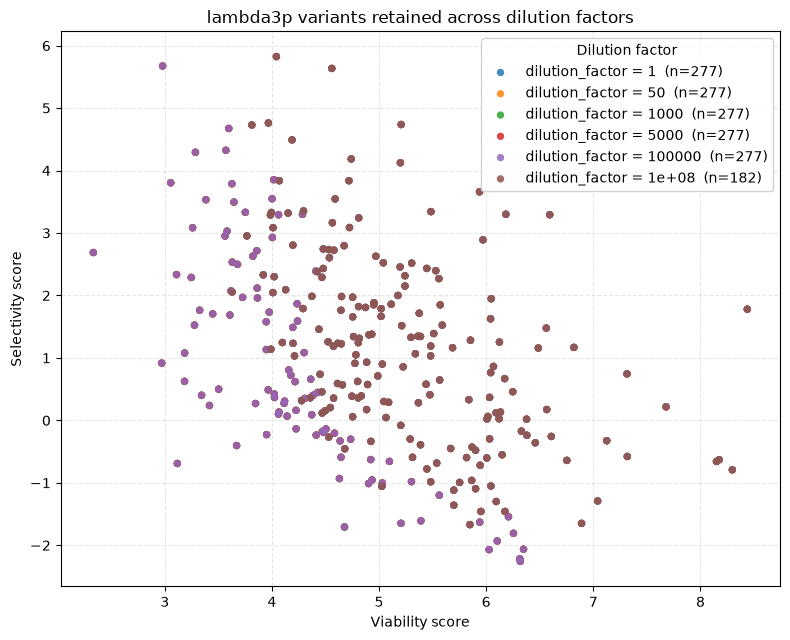

In [ ]:
protocol_multi_lownoise = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol_multi_lownoise.sequence shape:", protocol_multi_lownoise.sequence.shape, "  (identity, never changes)")
print("protocol_multi_lownoise.model     :", protocol_multi_lownoise.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol_multi_lownoise.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol_multi_lownoise, name).shape}")
    
lambdas_lownoise = protocol_multi_lownoise.N_loop_DE(3)
last_lambda0_lownoise, last_lambda1_lownoise, last_lambda2_lownoise, last_lambda3_lownoise, last_lambda4_lownoise = lambdas_lownoise[-1][0]
last_lambda0p_lownoise, last_lambda2p_lownoise, last_lambda3p_lownoise = lambdas_lownoise[-1][1]

for label, arr in [("lambda0", last_lambda0_lownoise), ("lambda1", last_lambda1_lownoise), ("lambda2", last_lambda2_lownoise),
                    ("lambda3", last_lambda3_lownoise), ("lambda4", last_lambda4_lownoise),
                    ("lambda0p", last_lambda0p_lownoise), ("lambda2p", last_lambda2p_lownoise), ("lambda3p", last_lambda3p_lownoise)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol_multi_lownoise.d0}")
    
dilution_factors_test = [1, 50, 1000, 5000, 1e5, 1e8]
fig = plot_lambda3p_dilution_scatter(protocol_multi_lownoise, dilution_factors_test)
plt.show()


In [ ]:
proportion_above_threshold(lambdas=lambdas_lownoise[-1][0], thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,47,140,247,395,482,500,504,504,504,504,504
lambda1,47,140,246,396,481,498,500,500,500,500,500
lambda2,0,161,215,266,277,277,277,277,277,277,277
lambda3,45,143,217,269,277,277,277,277,277,277,277
lambda4,45,143,217,269,277,277,277,277,277,277,277


protocol_multi_highnoise.sequence shape: (800000, 7)   (identity, never changes)
protocol_multi_highnoise.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Directed evolution rounds: 100%|██████████| 3/3 [00:02<00:00,  1.23it/s]


  lambda0    total=    99,997,752  non-zero= 503 / 800000
  lambda1    total=    10,006,281  non-zero= 463 / 800000
  lambda2    total=496,502,636,544  non-zero= 320 / 800000
  lambda3    total=358,369,067,008  non-zero= 319 / 800000
  lambda4    total=   100,007,888  non-zero= 315 / 800000
  lambda0p   total=10,003,681,101  non-zero= 461 / 800000
  lambda2p   total= 9,957,463,313  non-zero= 319 / 800000
  lambda3p   total=10,242,561,895  non-zero= 319 / 800000


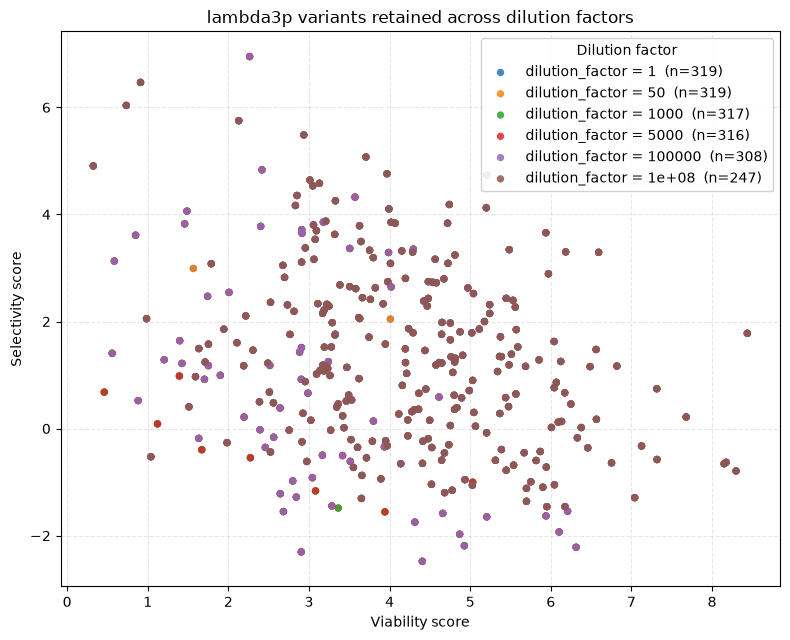

In [ ]:
protocol_multi_highnoise = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol_multi_highnoise.sequence shape:", protocol_multi_highnoise.sequence.shape, "  (identity, never changes)")
print("protocol_multi_highnoise.model     :", protocol_multi_highnoise.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol_multi_highnoise.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol_multi_highnoise, name).shape}")
    
lambdas_highnoise = protocol_multi_highnoise.N_loop_DE(3)
last_lambda0_highnoise, last_lambda1_highnoise, last_lambda2_highnoise, last_lambda3_highnoise, last_lambda4_highnoise = lambdas_highnoise[-1][0]
last_lambda0p_highnoise, last_lambda2p_highnoise, last_lambda3p_highnoise = lambdas_highnoise[-1][1]

for label, arr in [("lambda0", last_lambda0_highnoise), ("lambda1", last_lambda1_highnoise), ("lambda2", last_lambda2_highnoise),
                    ("lambda3", last_lambda3_highnoise), ("lambda4", last_lambda4_highnoise),
                    ("lambda0p", last_lambda0p_highnoise), ("lambda2p", last_lambda2p_highnoise), ("lambda3p", last_lambda3p_highnoise)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol_multi_highnoise.d0}")
    
dilution_factors_test = [1, 50, 1000, 5000, 1e5, 1e8]
fig = plot_lambda3p_dilution_scatter(protocol_multi_highnoise, dilution_factors_test)
plt.show()

In [ ]:
proportion_above_threshold(lambdas=lambdas_highnoise[-1][0], thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,210,299,365,415,457,503,503,503,503,503
lambda1,0,210,300,367,416,449,463,463,463,463,463
lambda2,0,238,263,287,300,310,317,318,319,319,320
lambda3,0,213,258,283,296,307,315,317,319,319,319
lambda4,0,213,258,283,297,308,314,315,315,315,315


## 6. Weight recovery test (`RegressionV1.py`) : impact of initial diversity

`RegressionV1.fit_weights_potts` / `ridge_cv_mse_potts` implement standard **L2 (Ridge) regression**: the normal equations solved are `(X^T X + lambda*I) w = X^T y` -- Tikhonov/L2 regularization added to the diagonal (the bias column is excluded from the penalty), the same closed-form Ridge fit used in `First_modelization/Potts_regression.ipynb`.

`recover_weights_from_NGS(protocol, n_rounds=...)` uses ONLY the observable NGS reads (`lambda0p`, `lambda2p`, `lambda3p`) pooled across `n_rounds` of `N_loop_DE` -- never the internal `lambda0..lambda4` ground truth -- to fit `F_viab`/`J_viab` (viability step) and `F_sel`/`J_sel` (selectivity step), then cross-validates the ridge penalty per step.

**Scale note:** the main `protocol` above uses the full library (`sequences`, ~hundreds of thousands of variants). At that scale the 8541-feature Ridge fit (140 single-site + 8400 pairwise + 1 bias) is not tractable here: a single solve on an 8541x8541 system already takes several seconds, and the feature matrix itself would need tens of GB of memory once pooled over multiple rounds of observed reads. This test therefore uses a smaller library sized for the regression demo, not the full-scale one.

In [ ]:
key_reg_smallN = jax.random.key(123)
key_reg_smallN, k_seq_reg_smallN = jax.random.split(key_reg_smallN)
N_reg_smallN = 2000
sequences_reg_smallN = jax.random.randint(k_seq_reg_smallN, shape=(N_reg_smallN, 7), minval=0, maxval=20)

protocol_reg_smallN = ProtocolV2(
    N0=1_000_000, N1=500_000, dilution_factor=10, sequences=sequences_reg_smallN, D=100_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat_smallN, J_viab_hat_smallN, F_sel_hat_smallN, J_sel_hat_smallN, info_smallN = reg.recover_weights_from_NGS(
    protocol_reg_smallN, n_rounds=1, k_folds=3,
)

results_smallN = reg.evaluate_recovery(protocol_reg_smallN, F_viab_hat_smallN, J_viab_hat_smallN, F_sel_hat_smallN, J_sel_hat_smallN)
print()
print(f"n_obs_viab = {info_smallN['n_obs_viab']}   n_obs_sel = {info_smallN['n_obs_sel']}")
print(f"best lambda (viab) = {info_smallN['lam_viab']:.3f}   best lambda (sel) = {info_smallN['lam_sel']:.3f}")
print()
for key, val in results_smallN.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 138 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


KeyboardInterrupt: 

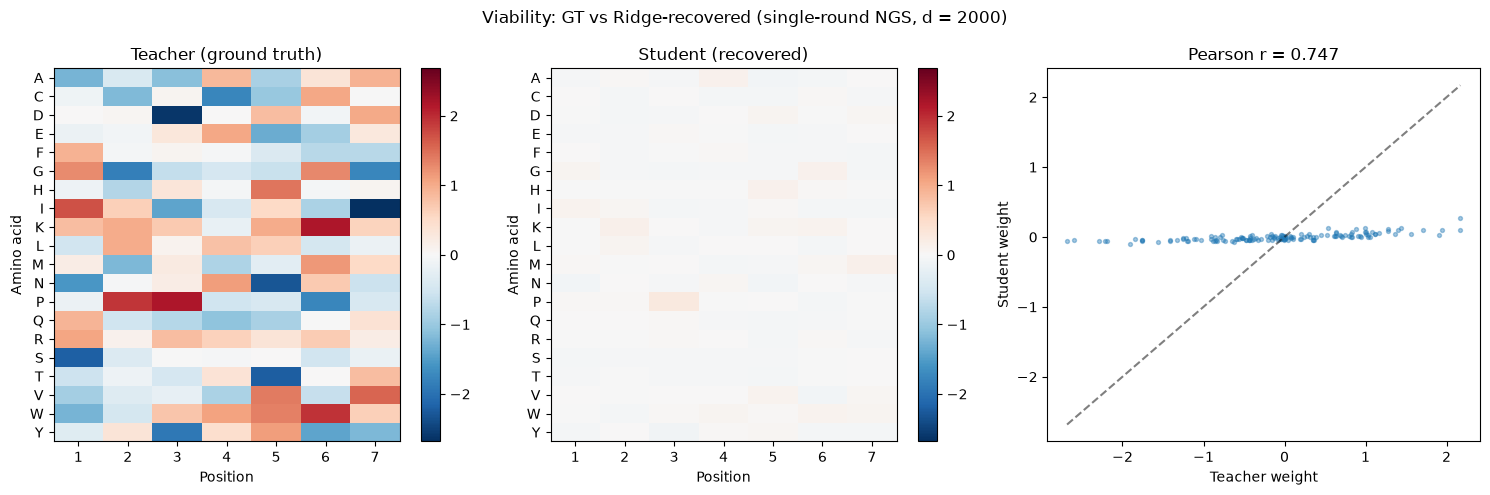

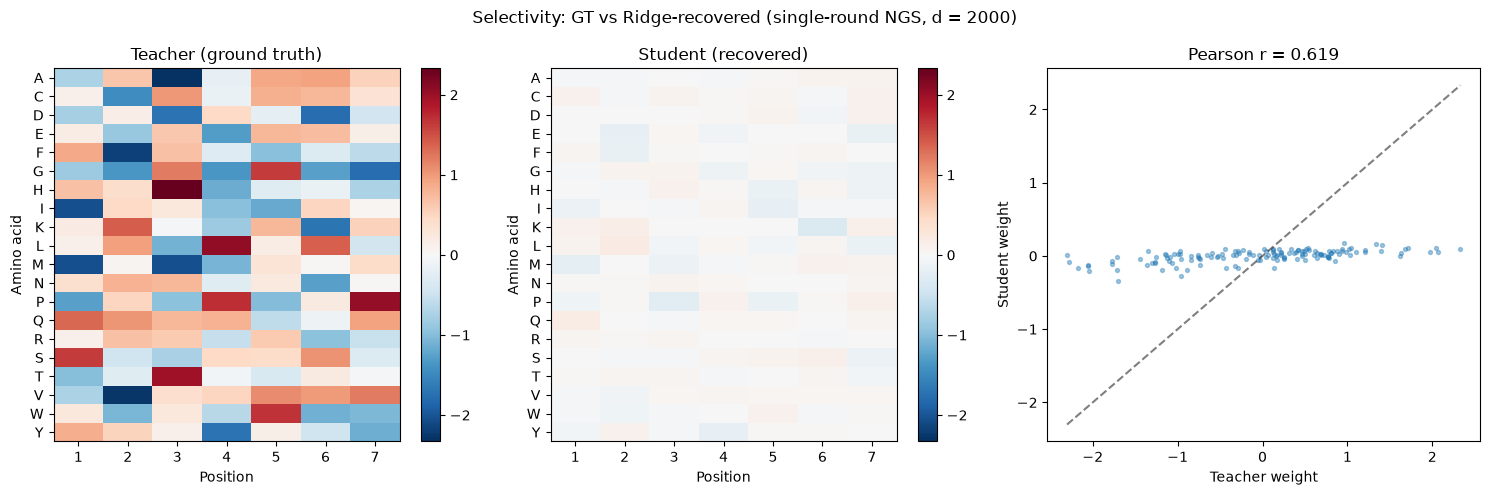

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_smallN, title=f"Viability: GT vs Ridge-recovered (single-round NGS, d = {N_reg_smallN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_smallN, title=f"Selectivity: GT vs Ridge-recovered (single-round NGS, d = {N_reg_smallN})")

Very clearly, the vaibility and selectivity phases are not understand by the model here, two options, either the phases are not discriminatory enough, either the noise is too loud and the model cannot understand the underlying rules for variants efficiency

Very clearly, the vaibility and selectivity phases are not understand by the model here, two options, either the phases are not discriminatory enough, either the noise is too loud and the model cannot understand the underlying rules for variants efficiency

In [ ]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 200000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=100_000_000, N1=1_000_000, dilution_factor=100, sequences=sequences_reg_largeN, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat_largeN, J_viab_hat_largeN, F_sel_hat_largeN, J_sel_hat_largeN, info_largeN = reg.recover_weights_from_NGS(
    protocol_reg_largeN, n_rounds=1, lambdas_grid=np.array([0.1]), k_folds=3,
)

print("F_viab_hat_largeN = {F_viab_hat_largeN}, J_viab_hat_largeN = {J_viab_hat_largeN}, F_sel_hat_largeN = {F_sel_hat_largeN}, J_sel_hat_largeN = {J_sel_hat_largeN}")
print("starting evaluating recovery")

results_largeN = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN, J_viab_hat_largeN, F_sel_hat_largeN, J_sel_hat_largeN)
print()
print(f"n_obs_viab = {info_largeN['n_obs_viab']}   n_obs_sel = {info_largeN['n_obs_sel']}")
print(f"best lambda (viab) = {info_largeN['lam_viab']:.3f}   best lambda (sel) = {info_largeN['lam_sel']:.3f}")
print()
for key, val in results_largeN.items():
    print(f'  {key:20s} : {val:.4f}')

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.45it/s]


Viability   dataset: 198651 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 696 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 0.1000
Best lambda (selectivity) : 0.1000
F_viab_hat_largeN = {F_viab_hat_largeN}, J_viab_hat_largeN = {J_viab_hat_largeN}, F_sel_hat_largeN = {F_sel_hat_largeN}, J_sel_hat_largeN = {J_sel_hat_largeN}
starting evaluating recovery

n_obs_viab = 198651   n_obs_sel = 696
best lambda (viab) = 0.100   best lambda (sel) = 0.100

  r_viab_scores        : 0.1092
  r_sel_scores         : 0.8507
  r_viab_weights       : 0.6607
  r_sel_weights        : 0.8949
  precision_at_1pct    : 0.2300
  precision_at_10pct   : 0.4137


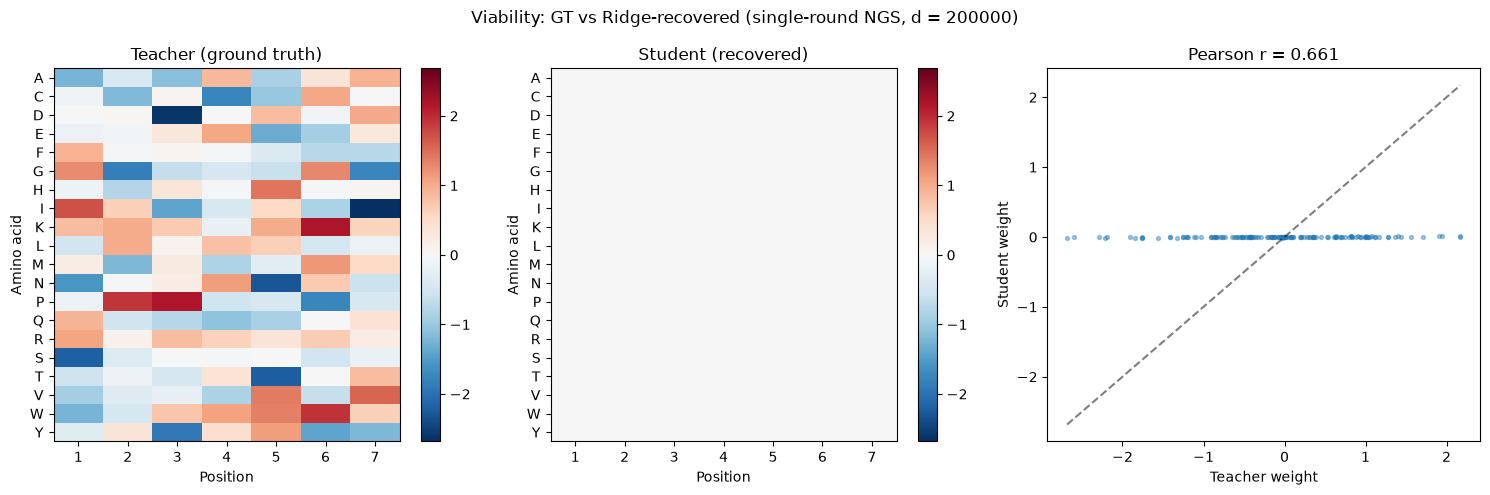

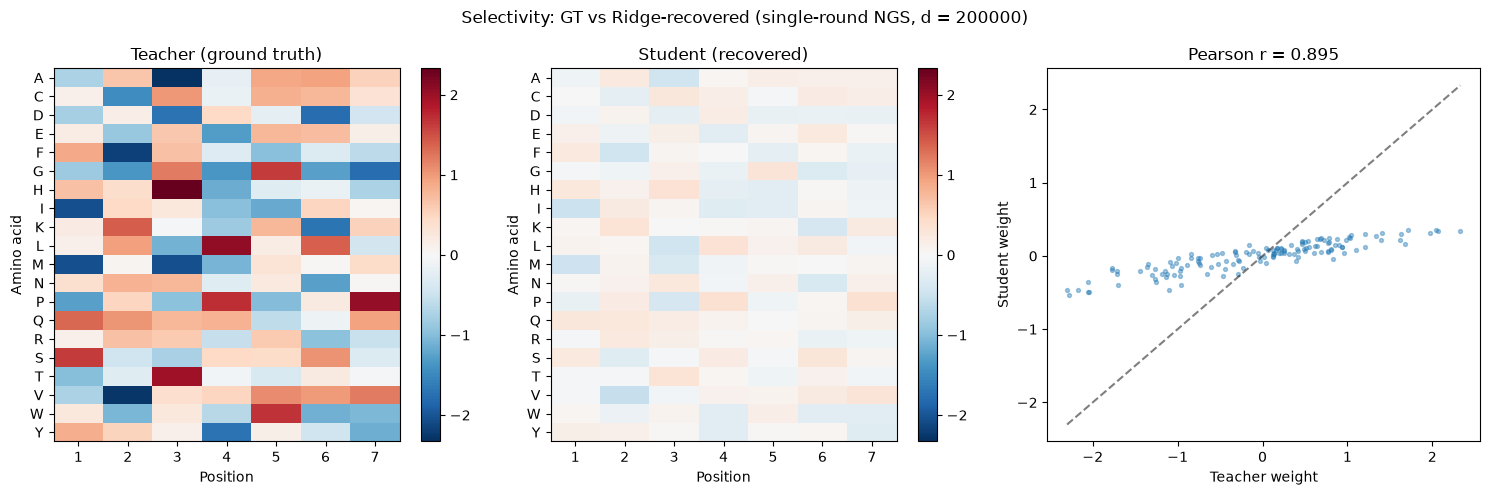

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN, title=f"Viability: GT vs Ridge-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN, title=f"Selectivity: GT vs Ridge-recovered (single-round NGS, d = {N_reg_largeN})")

## 6 ter. Unregularized (OLS) baseline -- same NGS datasets, no ridge penalty

`RegressionV1.fit_weights_potts_unregularized` / `recover_weights_unregularized_from_NGS` solve the same problem as `recover_weights_from_NGS` but with **no L2 penalty**: plain ordinary least squares via `np.linalg.lstsq` (minimum-norm solution) instead of `np.linalg.solve` on the ridge-regularized normal equations. There is no lambda grid and no CV step -- there's no hyperparameter to tune.

Reusing `protocol_reg_smallN` (d = 2000) and `protocol_reg_largeN` (d = 200000) from section 6. Note the one-hot Potts feature matrix (`build_potts_features`) is **structurally rank-deficient regardless of N**: for every position, its A one-hot columns sum to the bias column row-wise, and similarly each pairwise block collapses onto its single-site blocks -- so `X^T X` is singular by construction, not just because of a small sample. `recover_weights_unregularized_from_NGS` reports the numerical rank of each design matrix and warns whenever it falls short of `n_features`; expect that warning to fire even for `protocol_reg_largeN`. That structural singularity is exactly why `fit_weights_potts`'s ridge penalty floor exists -- this section shows what happens without it.

In [9]:
key_reg_smallN = jax.random.key(123)
key_reg_smallN, k_seq_reg_smallN = jax.random.split(key_reg_smallN)
N_reg_smallN = 2000
sequences_reg_smallN = jax.random.randint(k_seq_reg_smallN, shape=(N_reg_smallN, 7), minval=0, maxval=20)

protocol_reg_smallN = ProtocolV2(
    N0=1_000_000, N1=500_000, dilution_factor=10, sequences=sequences_reg_smallN, D=100_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat_smallN_ols, J_viab_hat_smallN_ols, F_sel_hat_smallN_ols, J_sel_hat_smallN_ols, info_smallN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_smallN, n_rounds=1,
)

results_smallN_ols = reg.evaluate_recovery(protocol_reg_smallN, F_viab_hat_smallN_ols, J_viab_hat_smallN_ols, F_sel_hat_smallN_ols, J_sel_hat_smallN_ols)
print()
print(f"n_obs_viab = {info_smallN_ols['n_obs_viab']} (rank {info_smallN_ols['rank_viab']} / {info_smallN_ols['n_features']})   "
      f"n_obs_sel = {info_smallN_ols['n_obs_sel']} (rank {info_smallN_ols['rank_sel']} / {info_smallN_ols['n_features']})")
print()
print("Ridge (section 6, CV'd lambda) vs OLS (unregularized), same protocol_reg_smallN:")
for key in results_smallN_ols.keys():
    print(f"  {key:20s} :  ols={results_smallN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.20s/it]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 138 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 2000 / 8541 features (2000 obs)
Selectivity design matrix rank: 138 / 8541 features (138 obs)

n_obs_viab = 2000 (rank 2000 / 8541)   n_obs_sel = 138 (rank 138 / 8541)

Ridge (section 6, CV'd lambda) vs OLS (unregularized), same protocol_reg_smallN:
  r_viab_scores        :  ols=0.3153
  r_sel_scores         :  ols=0.5529
  r_viab_weights       :  ols=0.7318
  r_sel_weights        :  ols=0.6182
  precision_at_1pct    :  ols=0.1500
  precision_at_10pct   :  ols=0.3050


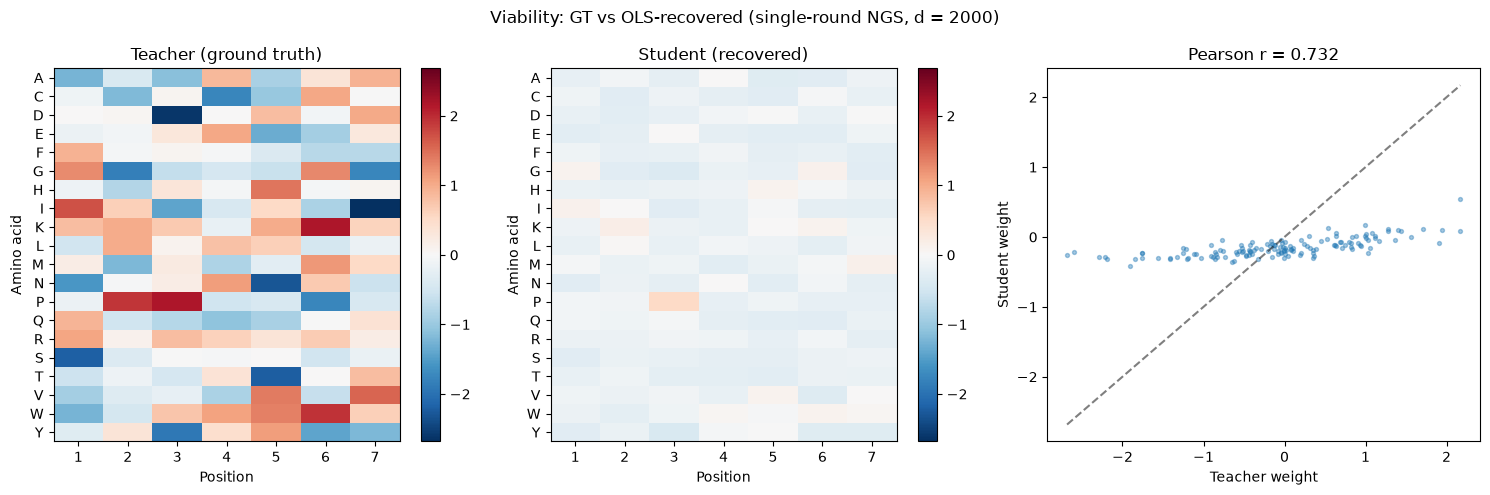

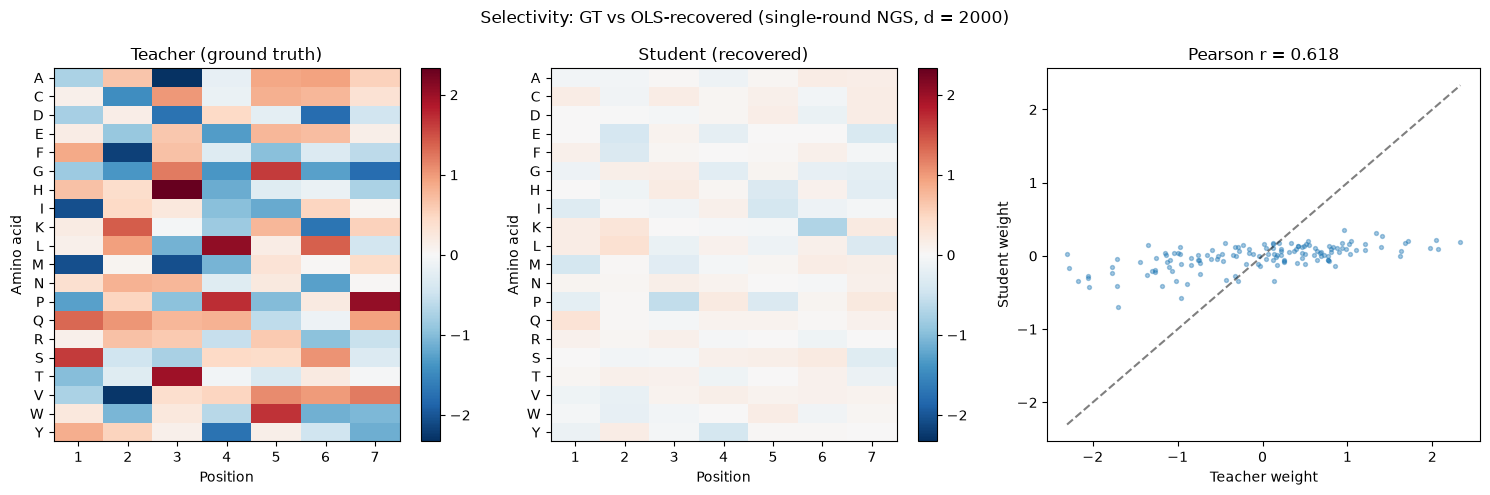

In [10]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_smallN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_smallN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_smallN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_smallN})")

In [11]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.30s/it]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 45471 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 7715 / 8541 features (50000 obs)
Selectivity design matrix rank: 7715 / 8541 features (45471 obs)

n_obs_viab = 50000 (rank 7715 / 8541)   n_obs_sel = 45471 (rank 7715 / 8541)

Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:
  r_viab_scores        :  ols=0.9904
  r_sel_scores         :  ols=0.8554
  r_viab_weights       :  ols=0.9945
  r_sel_weights        :  ols=0.9499
  precision_at_1pct    :  ols=0.4200
  precision_at_10pct   :  ols=0.6582


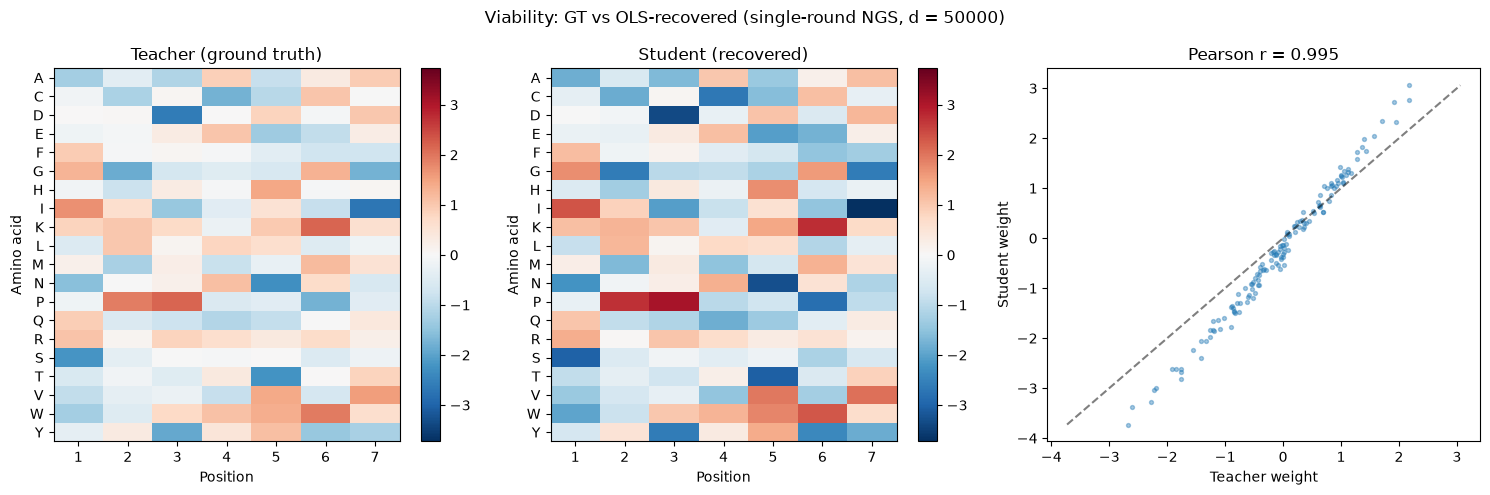

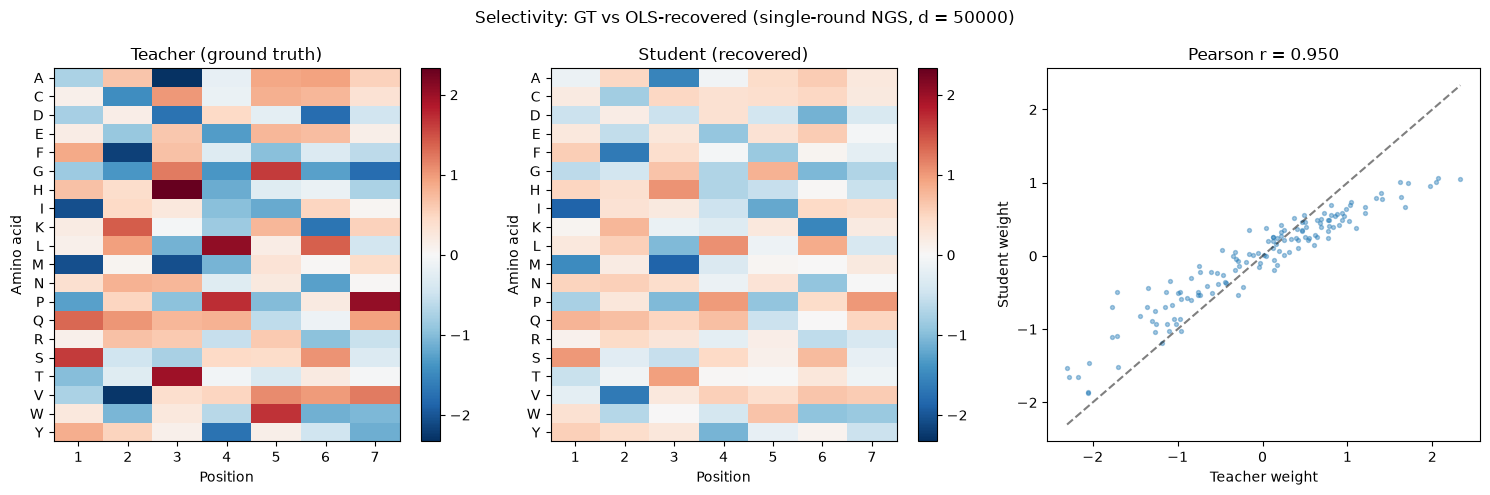

In [12]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

In [13]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=10
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 50000 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 7715 / 8541 features (50000 obs)
Selectivity design matrix rank: 7715 / 8541 features (50000 obs)

n_obs_viab = 50000 (rank 7715 / 8541)   n_obs_sel = 50000 (rank 7715 / 8541)

Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:
  r_viab_scores        :  ols=0.7934
  r_sel_scores         :  ols=0.8771
  r_viab_weights       :  ols=0.9892
  r_sel_weights        :  ols=0.9695
  precision_at_1pct    :  ols=0.0020
  precision_at_10pct   :  ols=0.3480


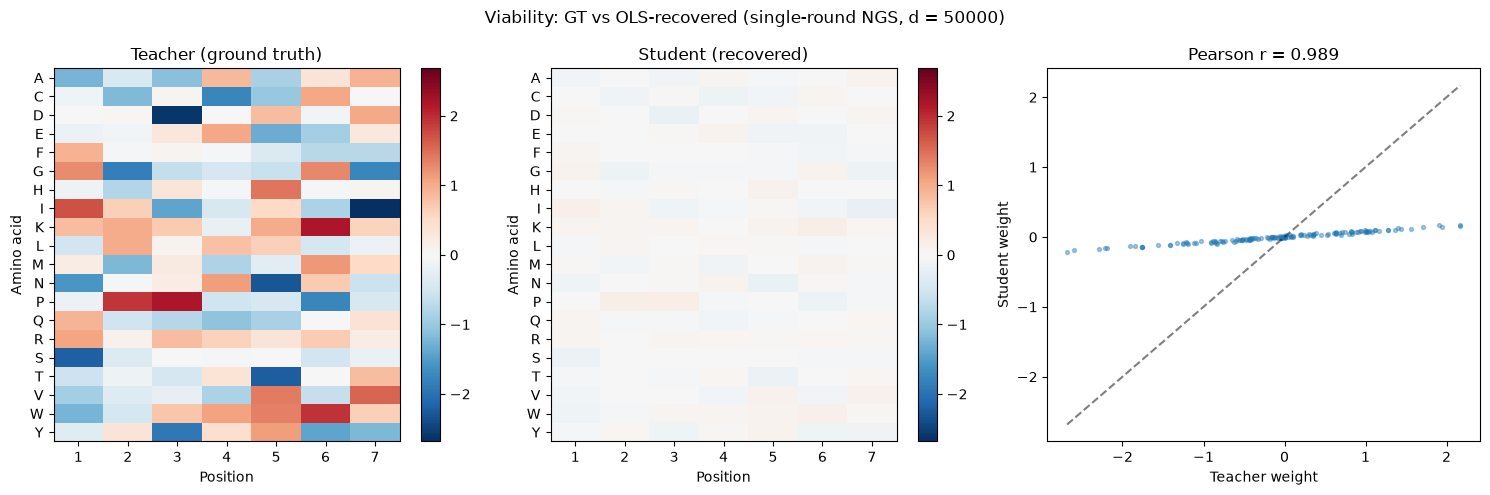

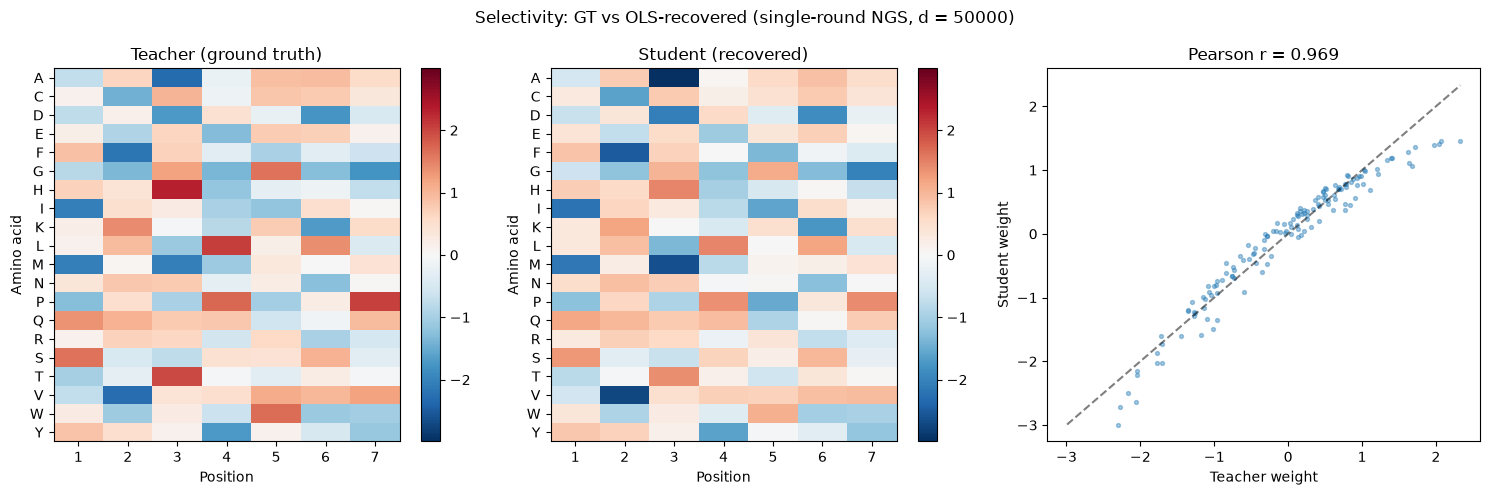

In [14]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

In [15]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_sel=10
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 45471 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 7715 / 8541 features (50000 obs)
Selectivity design matrix rank: 7715 / 8541 features (45471 obs)

n_obs_viab = 50000 (rank 7715 / 8541)   n_obs_sel = 45471 (rank 7715 / 8541)

Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:
  r_viab_scores        :  ols=0.9904
  r_sel_scores         :  ols=0.3846
  r_viab_weights       :  ols=0.9945
  r_sel_weights        :  ols=0.6432
  precision_at_1pct    :  ols=0.8780
  precision_at_10pct   :  ols=0.9356


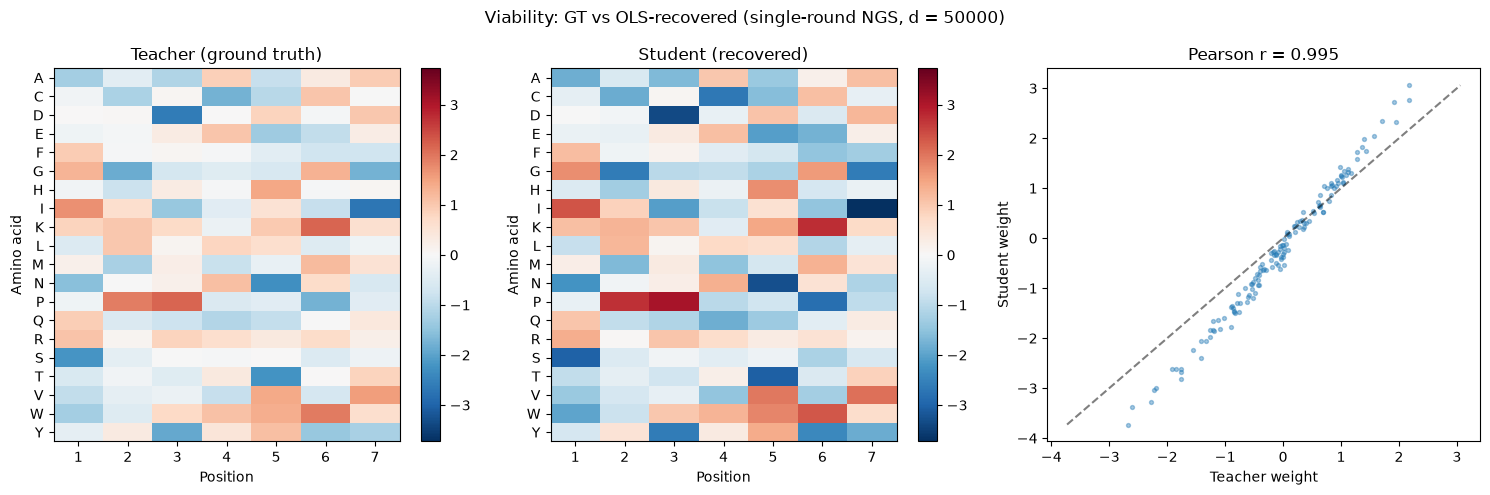

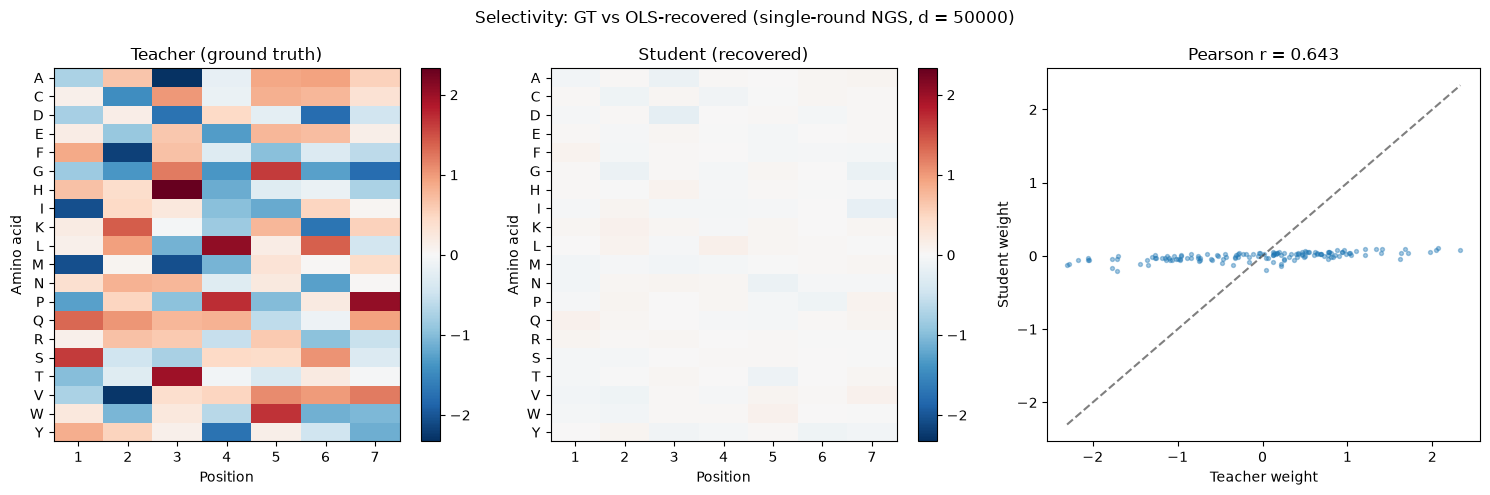

In [16]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

In [17]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=10, T_sel=10
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 50000 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 7715 / 8541 features (50000 obs)
Selectivity design matrix rank: 7715 / 8541 features (50000 obs)

n_obs_viab = 50000 (rank 7715 / 8541)   n_obs_sel = 50000 (rank 7715 / 8541)

Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:
  r_viab_scores        :  ols=0.7934
  r_sel_scores         :  ols=0.5933
  r_viab_weights       :  ols=0.9892
  r_sel_weights        :  ols=0.9688
  precision_at_1pct    :  ols=0.3040
  precision_at_10pct   :  ols=0.5000


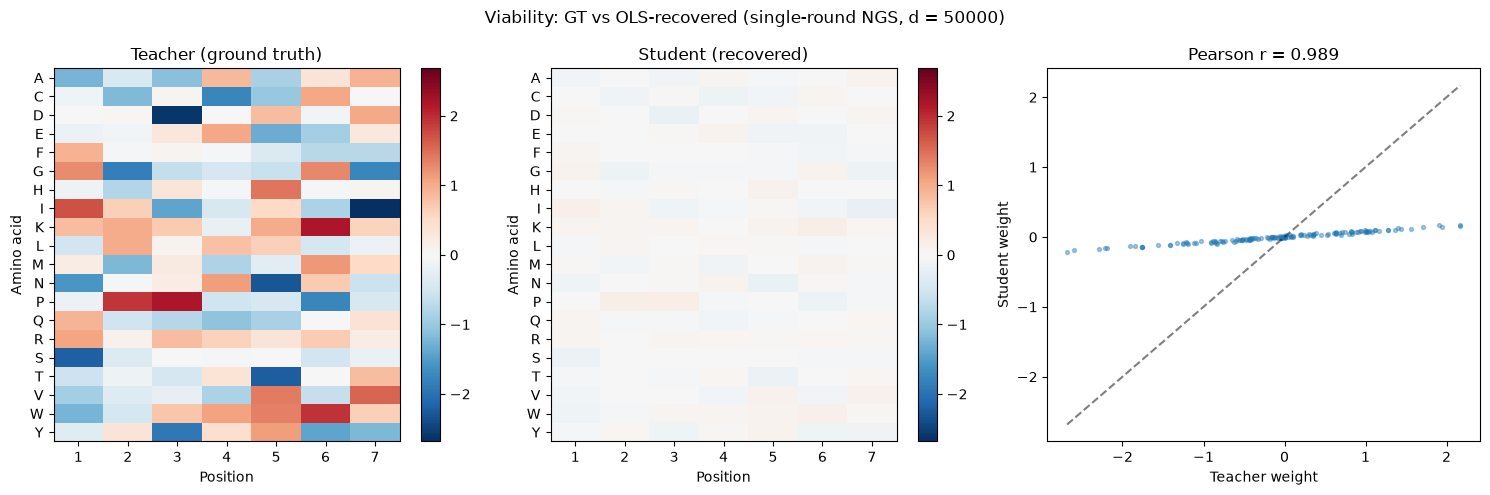

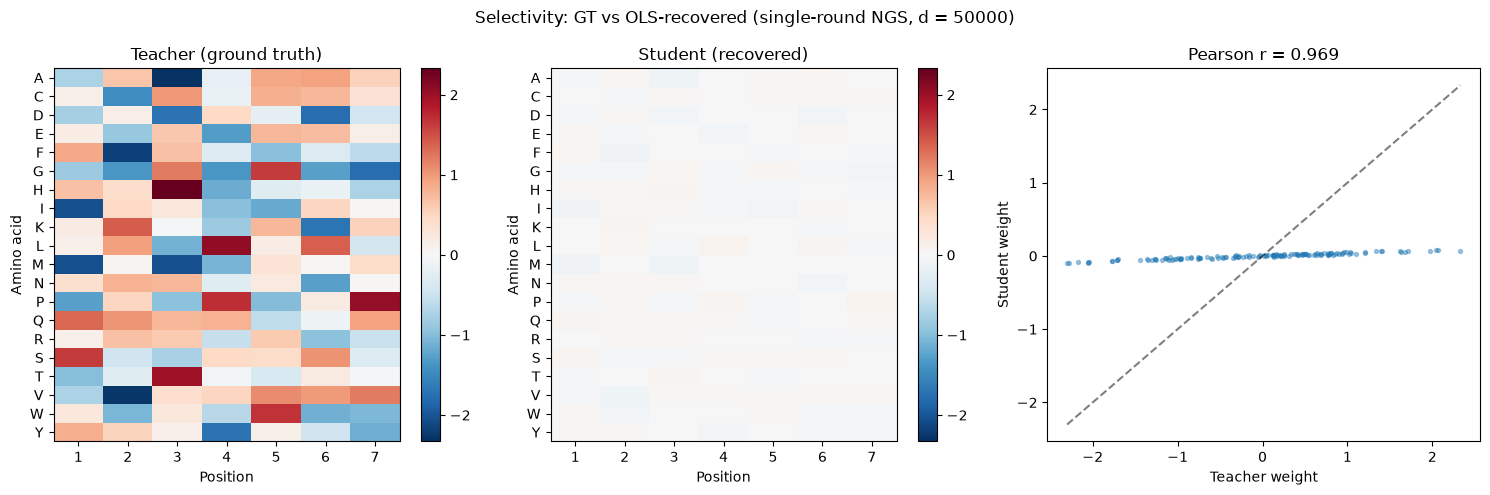

In [18]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

In [19]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=0.10, T_sel=0.10
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds:   0%|          | 0/1 [00:00<?, ?it/s]

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.46it/s]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 26330 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 7715 / 8541 features (50000 obs)
Selectivity design matrix rank: 7715 / 8541 features (26330 obs)

n_obs_viab = 50000 (rank 7715 / 8541)   n_obs_sel = 26330 (rank 7715 / 8541)

Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:
  r_viab_scores        :  ols=0.9359
  r_sel_scores         :  ols=0.2937
  r_viab_weights       :  ols=0.9911
  r_sel_weights        :  ols=0.3394
  precision_at_1pct    :  ols=0.0460
  precision_at_10pct   :  ols=0.4764


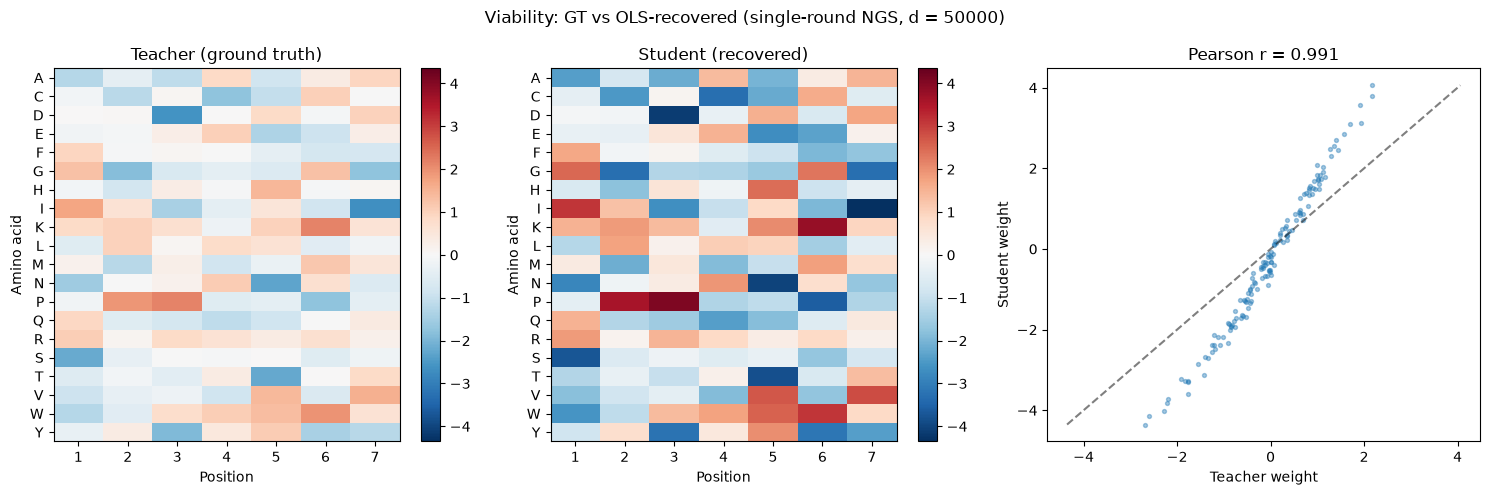

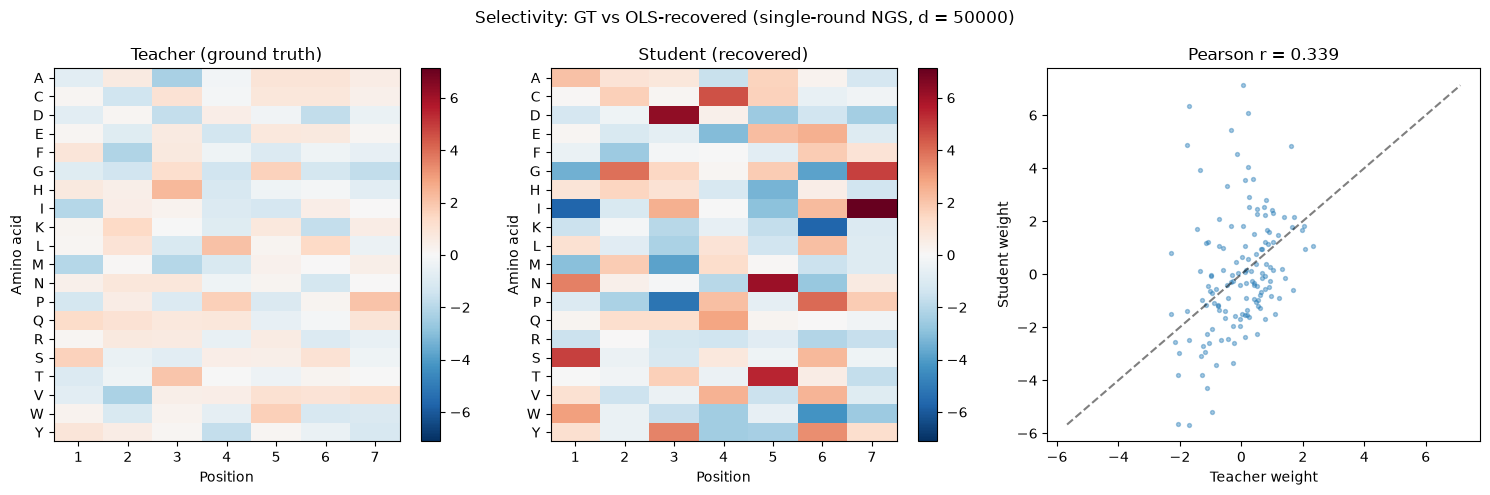

In [20]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

In [21]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0., noise_sel=0., T_viab=100, T_sel=100
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 50000 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features
Viability   design matrix rank: 7715 / 8541 features (50000 obs)
Selectivity design matrix rank: 7715 / 8541 features (50000 obs)

n_obs_viab = 50000 (rank 7715 / 8541)   n_obs_sel = 50000 (rank 7715 / 8541)

Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:
  r_viab_scores        :  ols=0.1357
  r_sel_scores         :  ols=0.0721
  r_viab_weights       :  ols=0.7046
  r_sel_weights        :  ols=0.4674
  precision_at_1pct    :  ols=0.0140
  precision_at_10pct   :  ols=0.1416


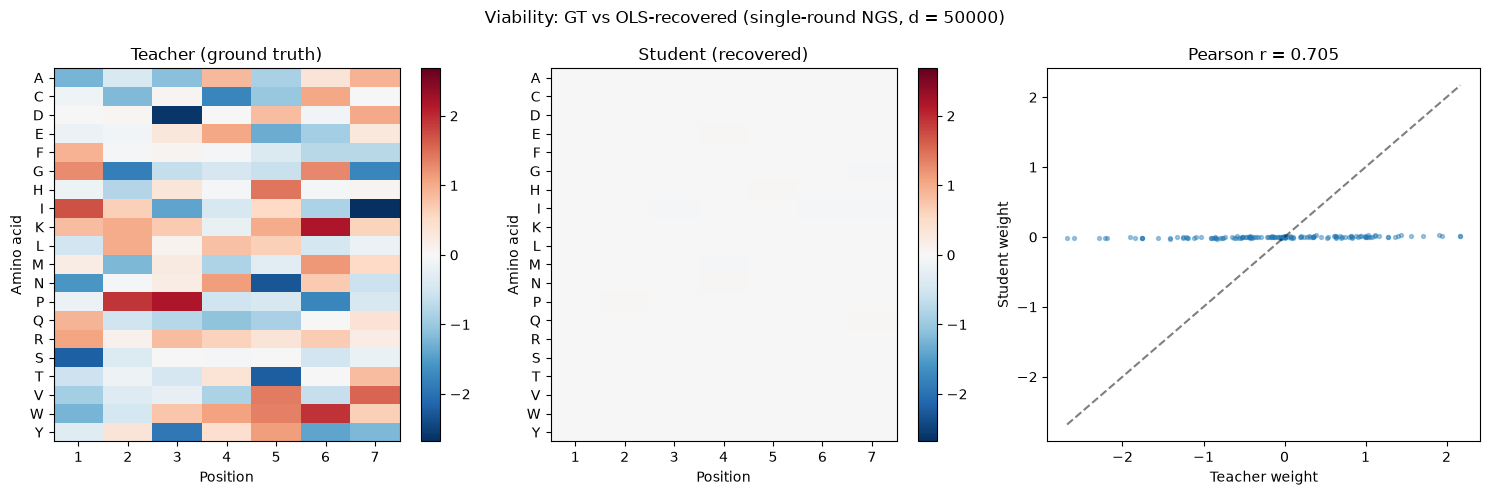

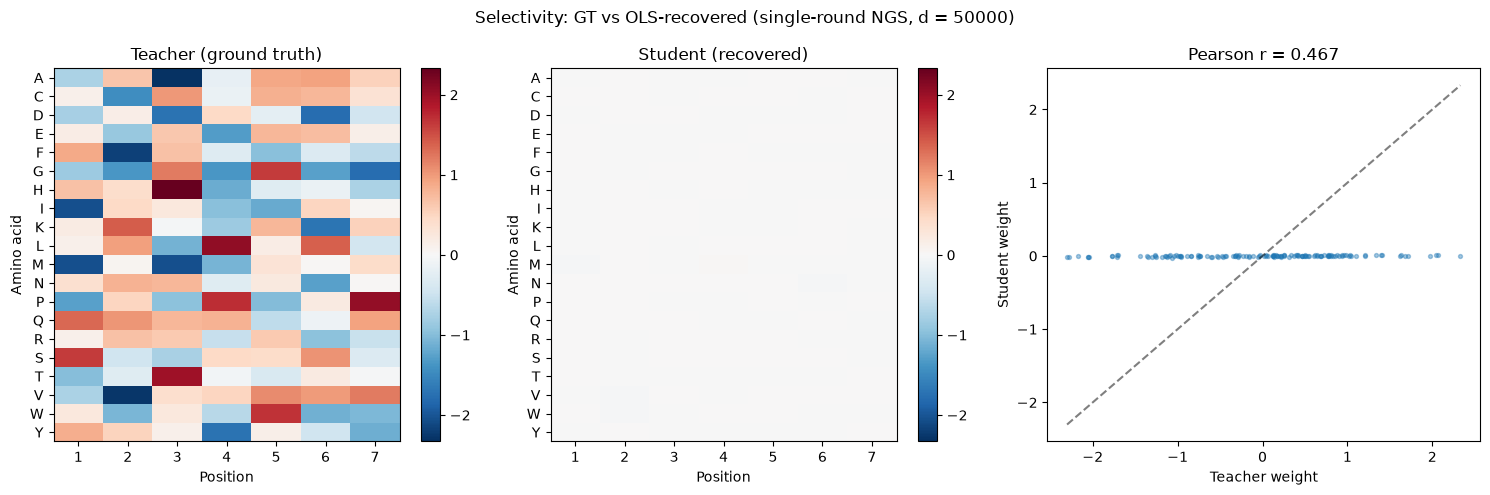

In [22]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

In [ ]:
key_reg_largeN = jax.random.key(123)
key_reg_largeN, k_seq_reg_largeN = jax.random.split(key_reg_largeN)
N_reg_largeN = 50000
sequences_reg_largeN = jax.random.randint(k_seq_reg_largeN, shape=(N_reg_largeN, 7), minval=0, maxval=20)

protocol_reg_largeN = ProtocolV2(
    N0=1_000_000_000, N1=1_000_000_000, dilution_factor=10, sequences=sequences_reg_largeN, D=100_000_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=0.50, T_sel=2
)

F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols, info_largeN_ols = reg.recover_weights_unregularized_from_NGS(
    protocol_reg_largeN, n_rounds=1,
)

results_largeN_ols = reg.evaluate_recovery(protocol_reg_largeN, F_viab_hat_largeN_ols, J_viab_hat_largeN_ols, F_sel_hat_largeN_ols, J_sel_hat_largeN_ols)
print()
print(f"n_obs_viab = {info_largeN_ols['n_obs_viab']} (rank {info_largeN_ols['rank_viab']} / {info_largeN_ols['n_features']})   "
      f"n_obs_sel = {info_largeN_ols['n_obs_sel']} (rank {info_largeN_ols['rank_sel']} / {info_largeN_ols['n_features']})")
print()
print("Ridge (section 6, lambda fixed at 0.1) vs OLS (unregularized), same protocol_reg_largeN:")
for key in results_largeN_ols.keys():
    print(f"  {key:20s} :  ols={results_largeN_ols[key]:.4f}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.43it/s]


Viability   dataset: 50000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 45471 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_largeN_ols, title=f"Viability: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_largeN_ols, title=f"Selectivity: GT vs OLS-recovered (single-round NGS, d = {N_reg_largeN})")

## 7. Weight recovery : impact of pressure for viability and selectivity phase

First only on Viability

In [ ]:
key_reg_pressure = jax.random.key(123)
key_reg_pressure, k_seq_reg_pressure = jax.random.split(key_reg_pressure)
N_reg_pressure = 2000
sequences_reg_pressure = jax.random.randint(k_seq_reg_pressure, shape=(N_reg_pressure, 7), minval=0, maxval=20)

####################################################################################
####################################################################################
new_T_viab = 10
new_T_sel  = 10
####################################################################################
####################################################################################

protocol_reg_viabpressure = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_pressure, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab
)

F_viab_hat_viabpressure, J_viab_hat_viabpressure, F_sel_hat_viabpressure, J_sel_hat_viabpressure, info_viabpressure = reg.recover_weights_from_NGS(
    protocol_reg_viabpressure, n_rounds=1, k_folds=3,
)

results_viabpressure = reg.evaluate_recovery(protocol_reg_viabpressure, F_viab_hat_viabpressure, J_viab_hat_viabpressure, F_sel_hat_viabpressure, J_sel_hat_viabpressure)
print()
print(f"n_obs_viab = {info_viabpressure['n_obs_viab']}   n_obs_sel = {info_viabpressure['n_obs_sel']}")
print(f"best lambda (viab) = {info_viabpressure['lam_viab']:.3f}   best lambda (sel) = {info_viabpressure['lam_sel']:.3f}")
print()
for key, val in results_viabpressure.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1988 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 1.0000

n_obs_viab = 2000   n_obs_sel = 1988
best lambda (viab) = 100.000   best lambda (sel) = 1.000

  r_viab_scores        : 0.5272
  r_sel_scores         : 0.8685
  r_viab_weights       : 0.6578
  r_sel_weights        : 0.9611
  precision_at_1pct    : 0.1500
  precision_at_10pct   : 0.3850


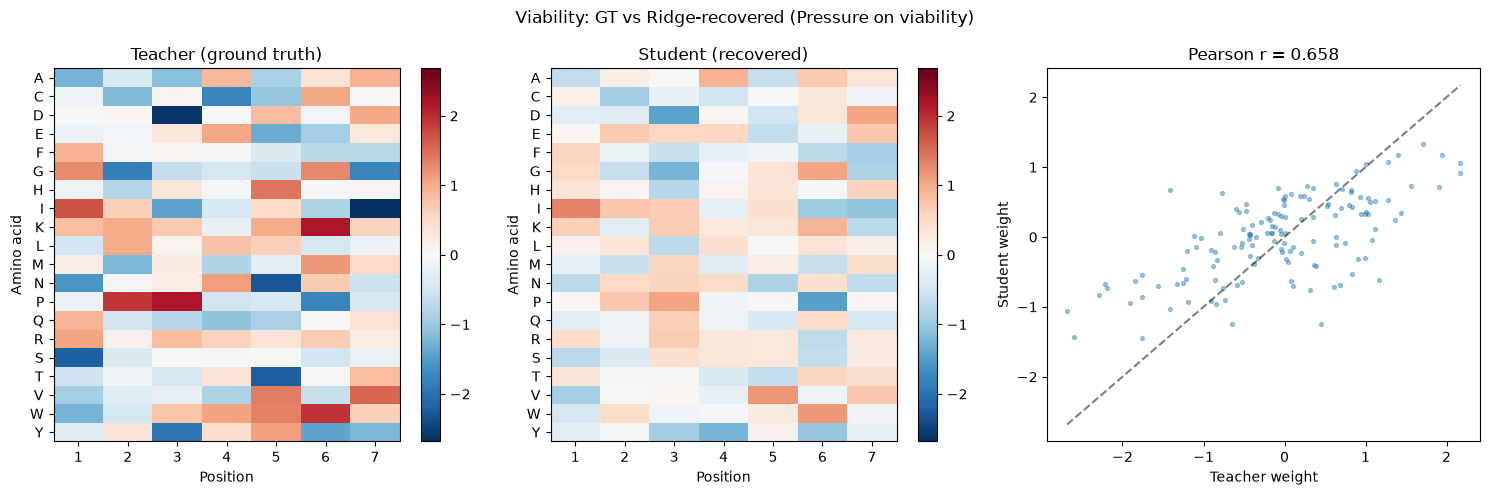

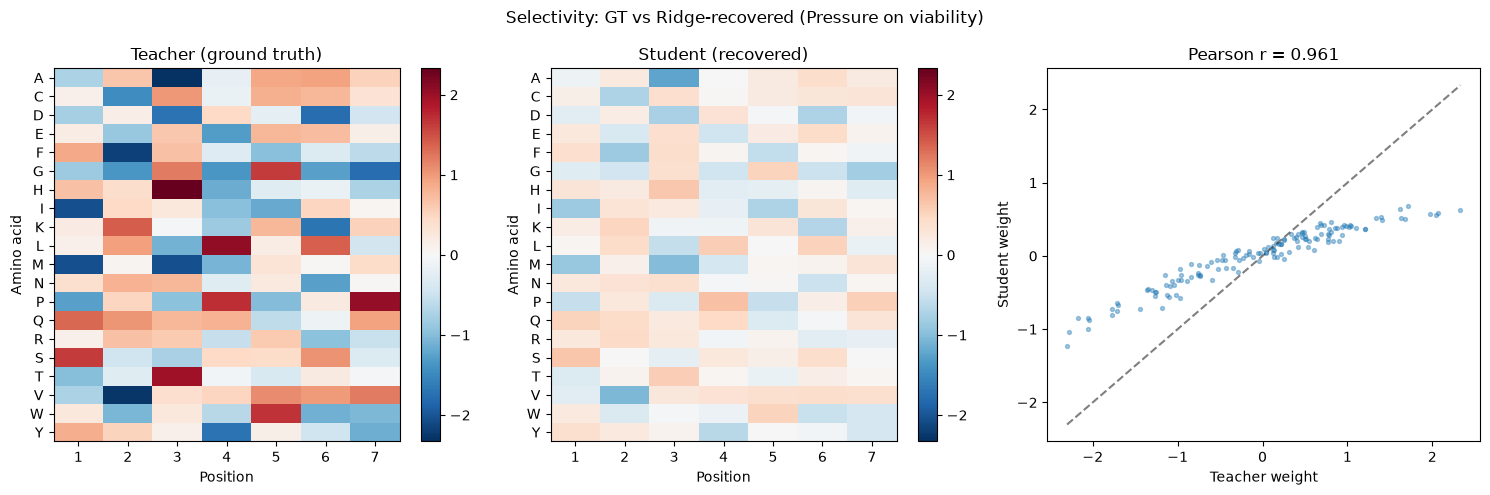

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_viabpressure, title="Viability: GT vs Ridge-recovered (Pressure on viability)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_viabpressure, title="Selectivity: GT vs Ridge-recovered (Pressure on viability)")

Then on selectivity

In [ ]:
key_reg_selpressure = jax.random.key(123)
key_reg_selpressure, k_seq_reg_selpressure = jax.random.split(key_reg_selpressure)
N_reg_selpressure = 2000
sequences_reg_selpressure = jax.random.randint(k_seq_reg_selpressure, shape=(N_reg_selpressure, 7), minval=0, maxval=20)

protocol_reg_selpressure = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_selpressure, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab = 0.5, T_sel=new_T_sel
)

F_viab_hat_selpressure, J_viab_hat_selpressure, F_sel_hat_selpressure, J_sel_hat_selpressure, info_selpressure = reg.recover_weights_from_NGS(
    protocol_reg_selpressure, n_rounds=1, k_folds=3,
)

results_selpressure = reg.evaluate_recovery(protocol_reg_selpressure, F_viab_hat_selpressure, J_viab_hat_selpressure, F_sel_hat_selpressure, J_sel_hat_selpressure)
print()
print(f"n_obs_viab = {info_selpressure['n_obs_viab']}   n_obs_sel = {info_selpressure['n_obs_sel']}")
print(f"best lambda (viab) = {info_selpressure['lam_viab']:.3f}   best lambda (sel) = {info_selpressure['lam_sel']:.3f}")
print()
for key, val in results_selpressure.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.55it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1425 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 0.1000
Best lambda (selectivity) : 316.2278

n_obs_viab = 2000   n_obs_sel = 1425
best lambda (viab) = 0.100   best lambda (sel) = 316.228

  r_viab_scores        : 0.9228
  r_sel_scores         : 0.4504
  r_viab_weights       : 0.9789
  r_sel_weights        : 0.4765
  precision_at_1pct    : 0.8000
  precision_at_10pct   : 0.9100


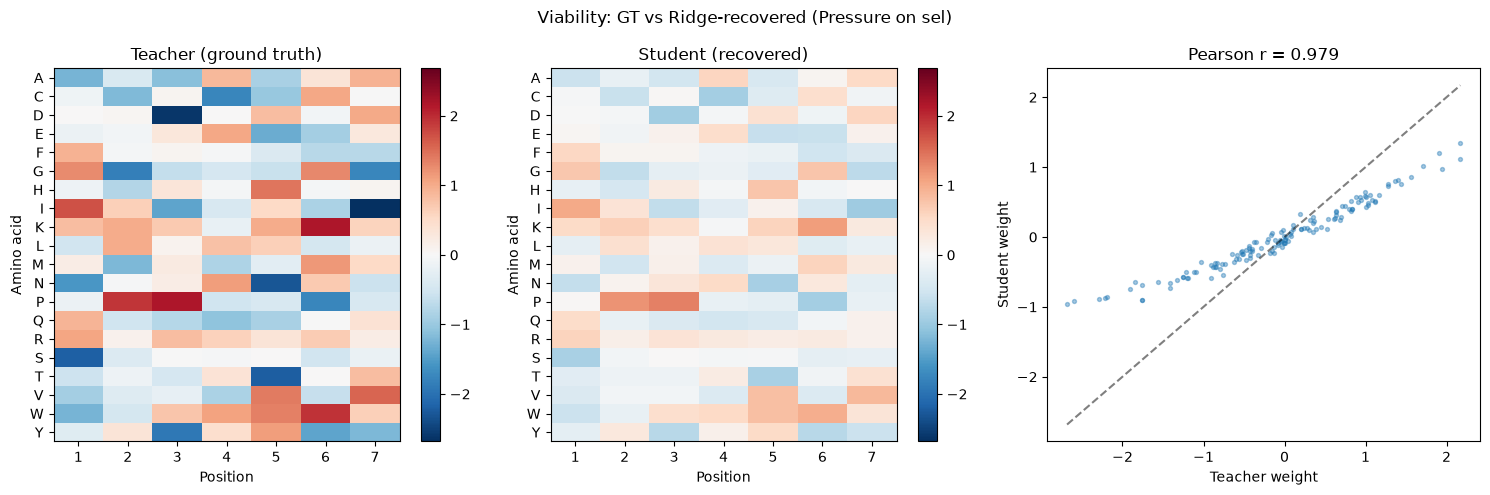

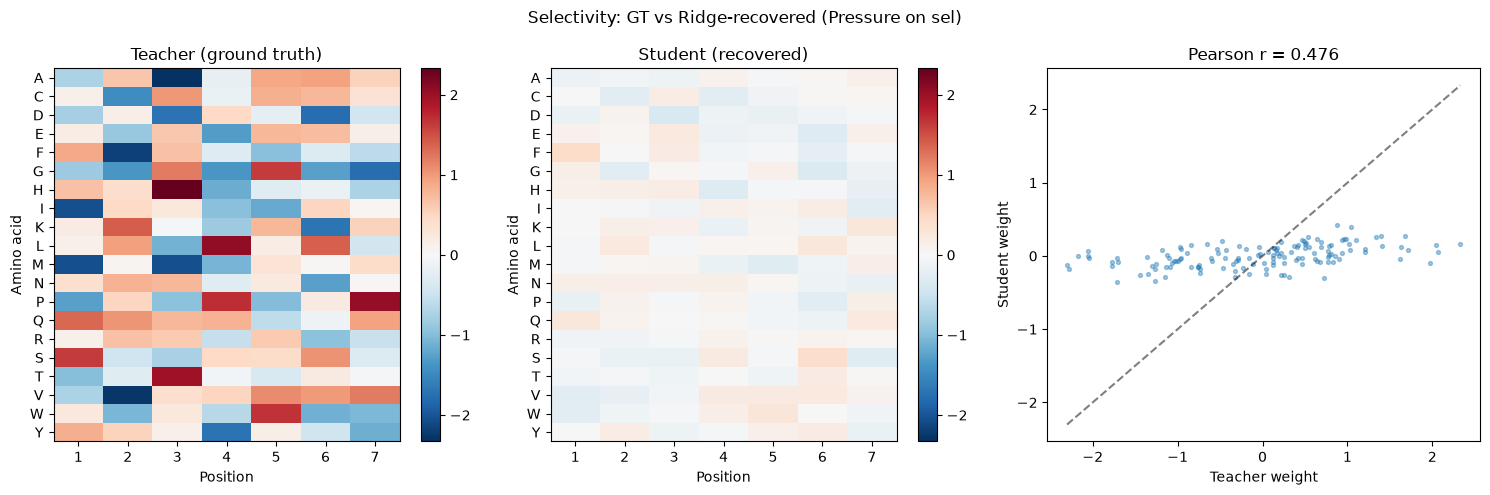

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_selpressure, title="Viability: GT vs Ridge-recovered (Pressure on sel)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_selpressure, title="Selectivity: GT vs Ridge-recovered (Pressure on sel)")

Finally on both

In [ ]:
key_reg_bothpressure = jax.random.key(123)
key_reg_bothpressure, k_seq_reg_bothpressure = jax.random.split(key_reg_bothpressure)
N_reg_bothpressure = 2000
sequences_reg_bothpressure = jax.random.randint(k_seq_reg_bothpressure, shape=(N_reg_bothpressure, 7), minval=0, maxval=20)

protocol_reg_bothpressure = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_bothpressure, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab, T_sel=new_T_sel
)

F_viab_hat_bothpressure, J_viab_hat_bothpressure, F_sel_hat_bothpressure, J_sel_hat_bothpressure, info_bothpressure = reg.recover_weights_from_NGS(
    protocol_reg_bothpressure, n_rounds=1, k_folds=3,
)

results_bothpressure = reg.evaluate_recovery(protocol_reg_bothpressure, F_viab_hat_bothpressure, J_viab_hat_bothpressure, F_sel_hat_bothpressure, J_sel_hat_bothpressure)
print()
print(f"n_obs_viab = {info_bothpressure['n_obs_viab']}   n_obs_sel = {info_bothpressure['n_obs_sel']}")
print(f"best lambda (viab) = {info_bothpressure['lam_viab']:.3f}   best lambda (sel) = {info_bothpressure['lam_sel']:.3f}")
print()
for key, val in results_bothpressure.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.94it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1988 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 100.0000

n_obs_viab = 2000   n_obs_sel = 1988
best lambda (viab) = 100.000   best lambda (sel) = 100.000

  r_viab_scores        : 0.5272
  r_sel_scores         : 0.6500
  r_viab_weights       : 0.6578
  r_sel_weights        : 0.7808
  precision_at_1pct    : 0.2500
  precision_at_10pct   : 0.4850


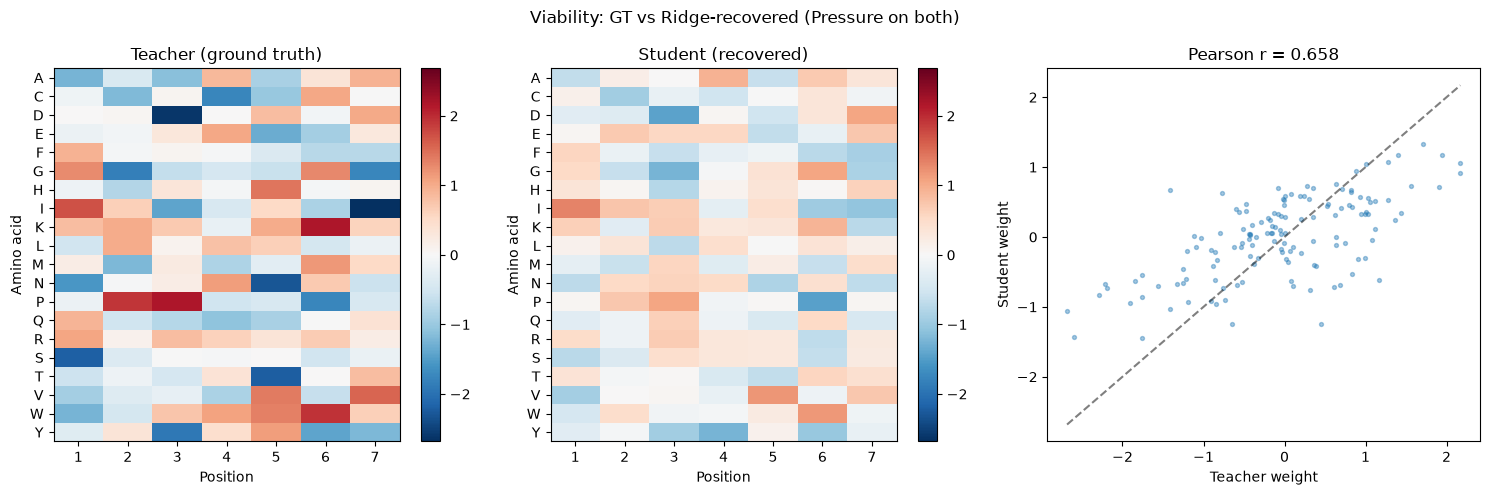

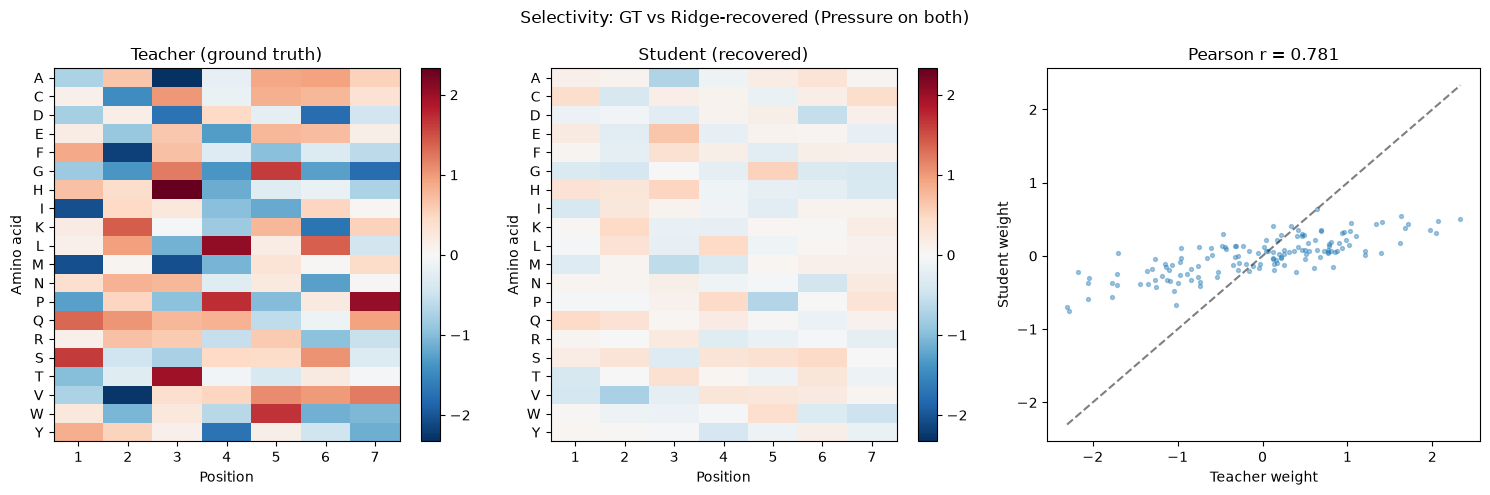

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_bothpressure, title="Viability: GT vs Ridge-recovered (Pressure on both)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_bothpressure, title="Selectivity: GT vs Ridge-recovered (Pressure on both)")

## 7 bis. Impact of pressure with no noise

In [ ]:
key_reg_bothpressuredenoised = jax.random.key(123)
key_reg_bothpressuredenoised, k_seq_reg_bothpressuredenoised = jax.random.split(key_reg_bothpressuredenoised)
N_reg_bothpressuredenoised = 20000
sequences_reg_bothpressuredenoised = jax.random.randint(k_seq_reg_bothpressuredenoised, shape=(N_reg_bothpressuredenoised, 7), minval=0, maxval=20)

protocol_reg_bothpressuredenoised = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_bothpressuredenoised, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0., noise_sel=0., T_viab=0.5, T_sel=new_T_sel
)

F_viab_hat_bothpressuredenoised, J_viab_hat_bothpressuredenoised, F_sel_hat_bothpressuredenoised, J_sel_hat_bothpressuredenoised, info_bothpressuredenoised = reg.recover_weights_from_NGS(
    protocol_reg_bothpressuredenoised, n_rounds=1, k_folds=3,
)

results_bothpressuredenoised = reg.evaluate_recovery(protocol_reg_bothpressuredenoised, F_viab_hat_bothpressuredenoised, J_viab_hat_bothpressuredenoised, F_sel_hat_bothpressuredenoised, J_sel_hat_bothpressuredenoised)
print()
print(f"n_obs_viab = {info_bothpressuredenoised['n_obs_viab']}   n_obs_sel = {info_bothpressuredenoised['n_obs_sel']}")
print(f"best lambda (viab) = {info_bothpressuredenoised['lam_viab']:.3f}   best lambda (sel) = {info_bothpressuredenoised['lam_sel']:.3f}")
print()
for key, val in results_bothpressuredenoised.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:04<00:00,  4.10s/it]


Viability   dataset: 20000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 4665 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 100.0000

n_obs_viab = 20000   n_obs_sel = 4665
best lambda (viab) = 100.000   best lambda (sel) = 100.000

  r_viab_scores        : 0.8884
  r_sel_scores         : 0.4484
  r_viab_weights       : 0.9709
  r_sel_weights        : 0.5148
  precision_at_1pct    : 0.4550
  precision_at_10pct   : 0.6965


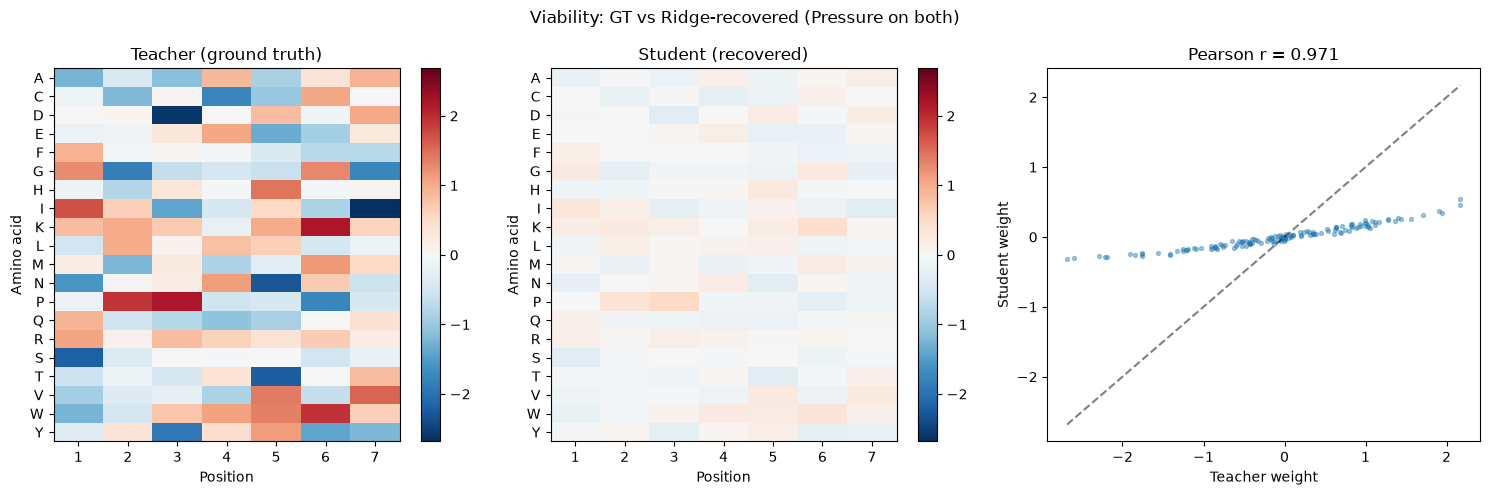

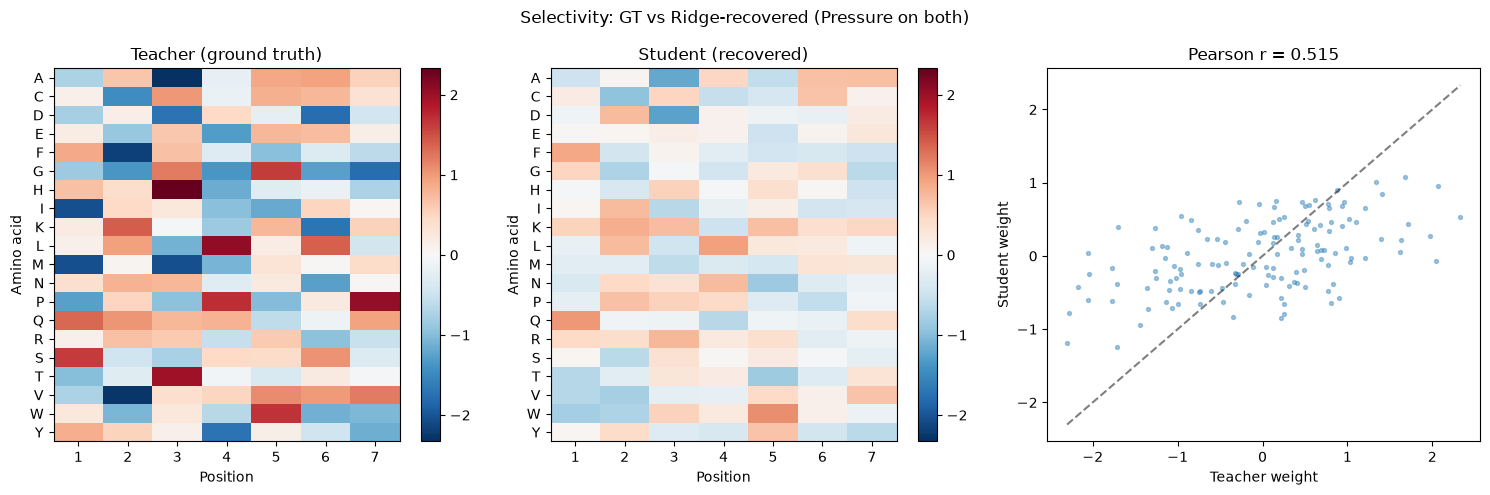

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_bothpressuredenoised, title="Viability: GT vs Ridge-recovered (Pressure on both)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_bothpressuredenoised, title="Selectivity: GT vs Ridge-recovered (Pressure on both)")

Trying to intensify selectivity (T_sel = 0.1) without noise

In [ ]:
key_reg_bothpressuredenoised2 = jax.random.key(123)
key_reg_bothpressuredenoised2, k_seq_reg_bothpressuredenoised2 = jax.random.split(key_reg_bothpressuredenoised2)
N_reg_bothpressuredenoised2 = 2000
sequences_reg_bothpressuredenoised2 = jax.random.randint(k_seq_reg_bothpressuredenoised2, shape=(N_reg_bothpressuredenoised2, 7), minval=0, maxval=20)

protocol_reg_bothpressuredenoised2 = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_bothpressuredenoised2, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0., noise_sel=0., T_viab=0.5, T_sel=100
)

F_viab_hat_bothpressuredenoised2, J_viab_hat_bothpressuredenoised2, F_sel_hat_bothpressuredenoised2, J_sel_hat_bothpressuredenoised2, info_bothpressuredenoised2 = reg.recover_weights_from_NGS(
    protocol_reg_bothpressuredenoised2, n_rounds=1, k_folds=3,
)

results_bothpressuredenoised2 = reg.evaluate_recovery(protocol_reg_bothpressuredenoised2, F_viab_hat_bothpressuredenoised2, J_viab_hat_bothpressuredenoised2, F_sel_hat_bothpressuredenoised2, J_sel_hat_bothpressuredenoised2)
print()
print(f"n_obs_viab = {info_bothpressuredenoised2['n_obs_viab']}   n_obs_sel = {info_bothpressuredenoised2['n_obs_sel']}")
print(f"best lambda (viab) = {info_bothpressuredenoised2['lam_viab']:.3f}   best lambda (sel) = {info_bothpressuredenoised2['lam_sel']:.3f}")
print()
for key, val in results_bothpressuredenoised2.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1423 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 0.1000
Best lambda (selectivity) : 1000.0000

n_obs_viab = 2000   n_obs_sel = 1423
best lambda (viab) = 0.100   best lambda (sel) = 1000.000

  r_viab_scores        : 0.9187
  r_sel_scores         : 0.0473
  r_viab_weights       : 0.9810
  r_sel_weights        : 0.0683
  precision_at_1pct    : 0.8500
  precision_at_10pct   : 0.8700


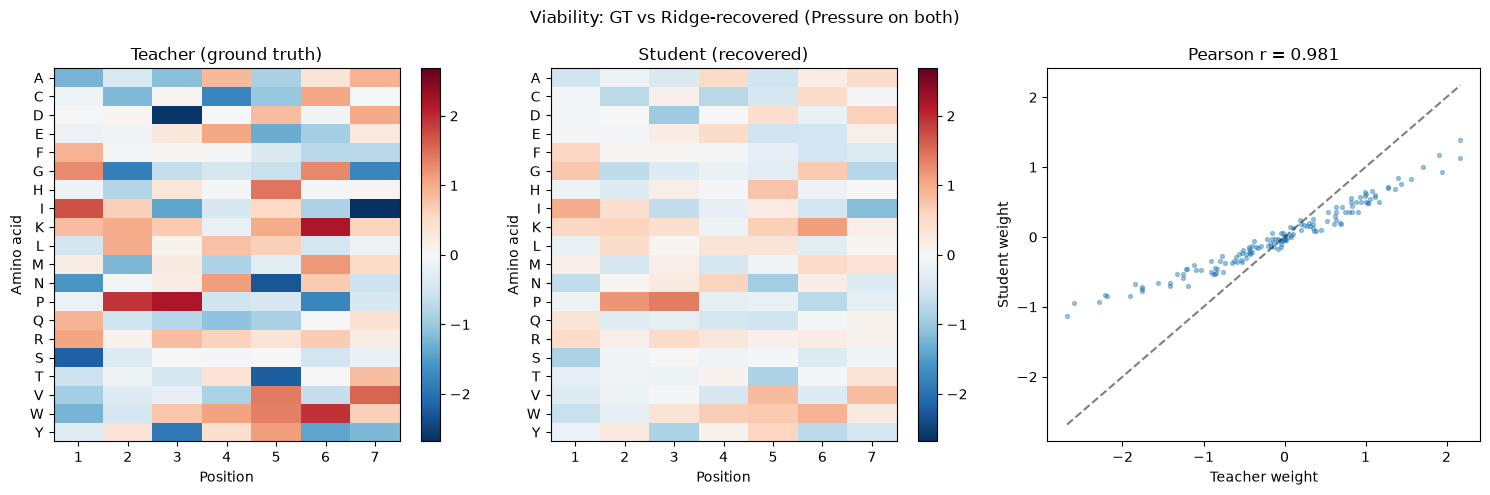

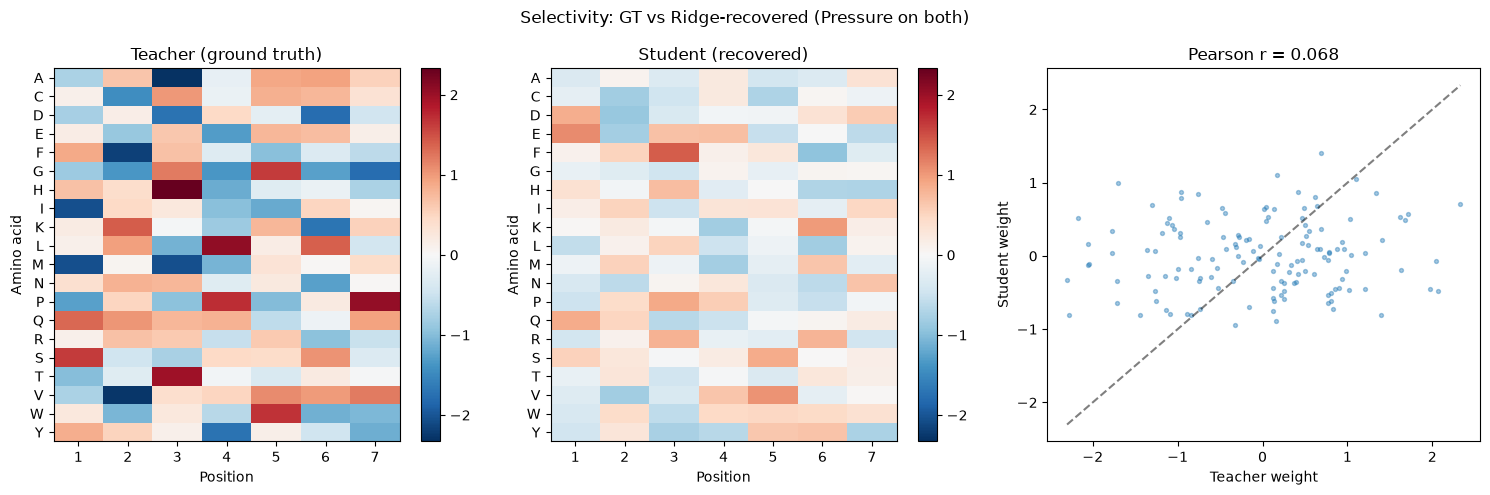

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_bothpressuredenoised2, title="Viability: GT vs Ridge-recovered (Pressure on both)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_bothpressuredenoised2, title="Selectivity: GT vs Ridge-recovered (Pressure on both)")

## 8. Weights recovery : impact of using diversity loop

In [ ]:
key_reg_parallel = jax.random.key(123)
key_reg_parallel, k_seq_reg_parallel = jax.random.split(key_reg_parallel)
N_reg_parallel = 10_000
N_split = 2
sequences_reg_parallel = jax.random.randint(k_seq_reg_parallel, shape=(N_reg_parallel, 7), minval=0, maxval=20)

sequences_reg_split = jnp.split(sequences_reg_parallel, N_split)
F_viab_hat_list, J_viab_hat_list, F_sel_hat_list, J_sel_hat_list, info_list = [], [], [], [], []

for i in range(N_split):
    protocol_reg_parallel = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_split[i], D=100_000_000,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1,
    )

    F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
        protocol_reg_parallel, n_rounds=1, k_folds=3,
    )
    F_viab_hat_list.append(F_viab_hat)
    J_viab_hat_list.append(J_viab_hat)
    F_sel_hat_list.append(F_sel_hat)
    J_sel_hat_list.append(J_sel_hat)
    info_list.append(info)

F_viab_hat_list = jnp.array(F_viab_hat_list)
J_viab_hat_list = jnp.array(J_viab_hat_list)
F_sel_hat_list  = jnp.array(F_sel_hat_list)
J_sel_hat_list  = jnp.array(J_sel_hat_list)

F_viab_hat_avg = jnp.mean(F_viab_hat_list, axis=0)
J_viab_hat_avg = jnp.mean(J_viab_hat_list, axis=0)
F_sel_hat_avg  = jnp.mean(F_sel_hat_list, axis=0)
J_sel_hat_avg  = jnp.mean(J_sel_hat_list, axis=0)

results_parallel = reg.evaluate_recovery(protocol_reg_parallel, F_viab_hat_avg, J_viab_hat_avg, F_sel_hat_avg, J_sel_hat_avg)

for i in range(N_split):
    print()
    print(f"n_obs_viab = {info_list[i]['n_obs_viab']}   n_obs_sel = {info_list[i]['n_obs_sel']}")
    print(f"best lambda (viab) = {info_list[i]['lam_viab']:.3f}   best lambda (sel) = {info_list[i]['lam_sel']:.3f}")

print()
for key, val in results_parallel.items():
    print(f'  {key:20s} : {val:.4f}')

lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:03<00:00,  3.85s/it]


Viability   dataset: 5000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 2775 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 31.6228
Best lambda (selectivity) : 10.0000
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.65it/s]


Viability   dataset: 5000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 2813 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 31.6228
Best lambda (selectivity) : 10.0000

n_obs_viab = 5000   n_obs_sel = 2775
best lambda (viab) = 31.623   best lambda (sel) = 10.000

n_obs_viab = 5000   n_obs_sel = 2813
best lambda (viab) = 31.623   best lambda (sel) = 10.000

  r_viab_scores        : 0.9565
  r_sel_scores         : 0.9082
  r_viab_weights       : 0.9802
  r_sel_weights        : 0.9410
  precision_at_1pct    : 0.5200
  precision_at_10pct   : 0.6760


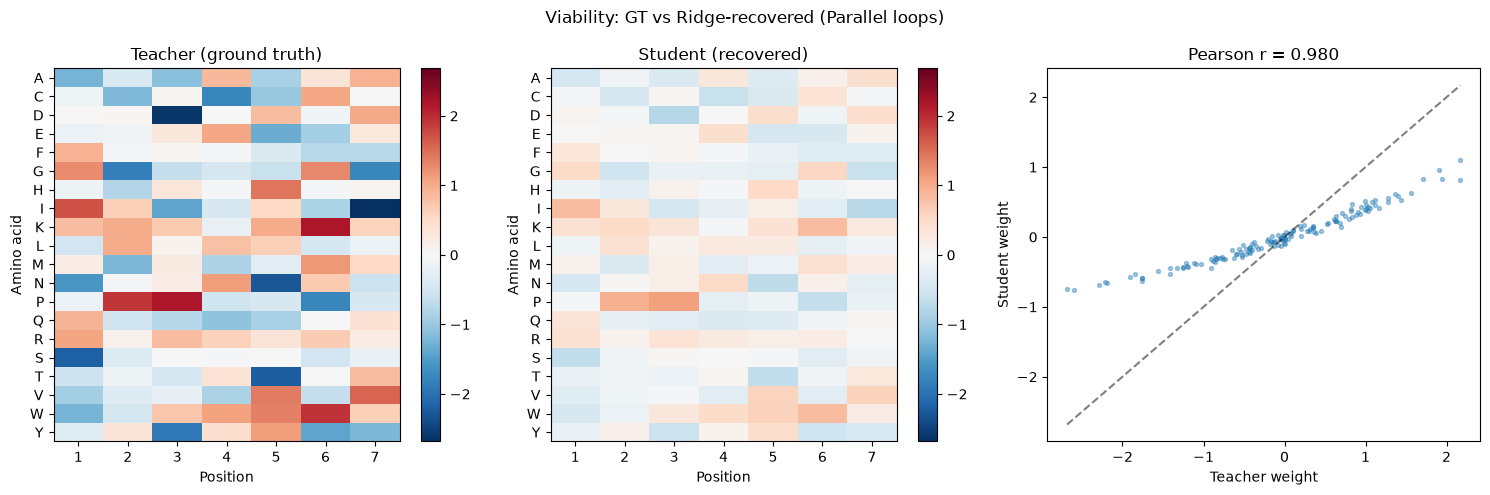

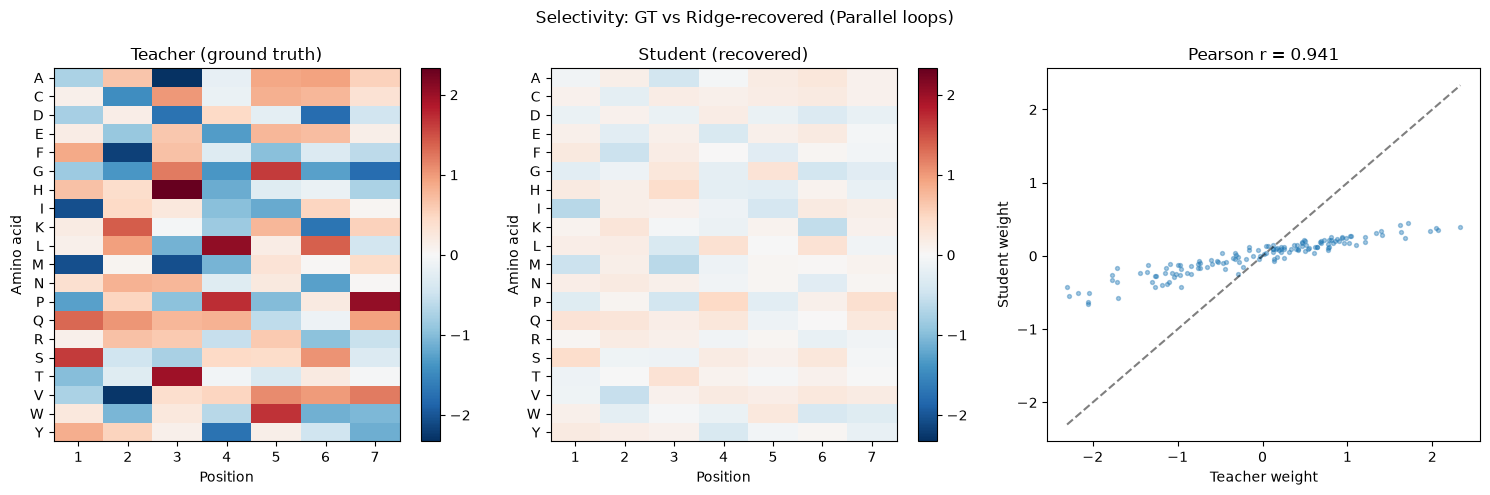

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_avg, title="Viability: GT vs Ridge-recovered (Parallel loops)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_avg, title="Selectivity: GT vs Ridge-recovered (Parallel loops)")

## 8 bis. Comparison with diversity

In [ ]:
key_reg_diversity = jax.random.key(123)
key_reg_diversity, k_seq_reg_diversity = jax.random.split(key_reg_diversity)
N_reg_diversity = 10_000
sequences_reg_diversity = jax.random.randint(k_seq_reg_diversity, shape=(N_reg_diversity, 7), minval=0, maxval=20)


protocol_reg_diversity = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_split[i], D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg_diversity, n_rounds=1, k_folds=3,
)


results_diversity = reg.evaluate_recovery(protocol_reg_diversity, F_viab_hat_avg, J_viab_hat_avg, F_sel_hat_avg, J_sel_hat_avg)

for i in range(N_split):
    print()
    print(f"n_obs_viab = {info_list[i]['n_obs_viab']}   n_obs_sel = {info_list[i]['n_obs_sel']}")
    print(f"best lambda (viab) = {info_list[i]['lam_viab']:.3f}   best lambda (sel) = {info_list[i]['lam_sel']:.3f}")

print()
for key, val in results_diversity.items():
    print(f'  {key:20s} : {val:.4f}')


## 9. Weights recovery : Impact of the NGS's depth

1000.0
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.17it/s]


Viability   dataset: 774 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 711 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 3162.2777
Best lambda (selectivity) : 1000000.0000

n_obs_viab = 774   n_obs_sel = 711
best lambda (viab) = 3162.278   best lambda (sel) = 1000000.000

  r_viab_scores        : 0.2894
  r_sel_scores         : 0.1110
  r_viab_weights       : 0.3025
  r_sel_weights        : 0.1280
  precision_at_1pct    : 0.0500
  precision_at_10pct   : 0.2250
100000.0
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]


...

Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1988 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 316.2278
Best lambda (selectivity) : 100.0000

n_obs_viab = 2000   n_obs_sel = 1988
best lambda (viab) = 316.228   best lambda (sel) = 100.000

  r_viab_scores        : 0.4522
  r_sel_scores         : 0.6494
  r_viab_weights       : 0.5243
  r_sel_weights        : 0.7794
  precision_at_1pct    : 0.2500
  precision_at_10pct   : 0.4350
10000000000000.0
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


Viability   dataset: 2000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 1988 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 316.2278
Best lambda (selectivity) : 100.0000

n_obs_viab = 2000   n_obs_sel = 1988
best lambda (viab) = 316.228   best lambda (sel) = 100.000

  r_viab_scores        : 0.0418
  r_sel_scores         : 0.3349
  r_viab_weights       : 0.0592
  r_sel_weights        : 0.4263
  precision_at_1pct    : 0.0000
  precision_at_10pct   : 0.1650


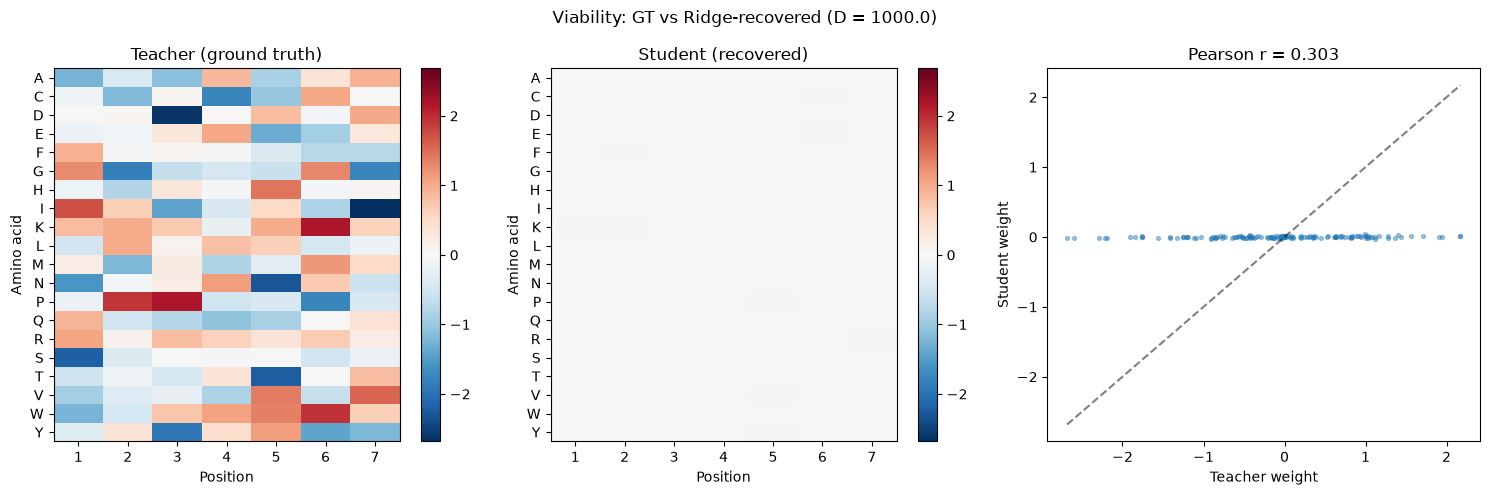

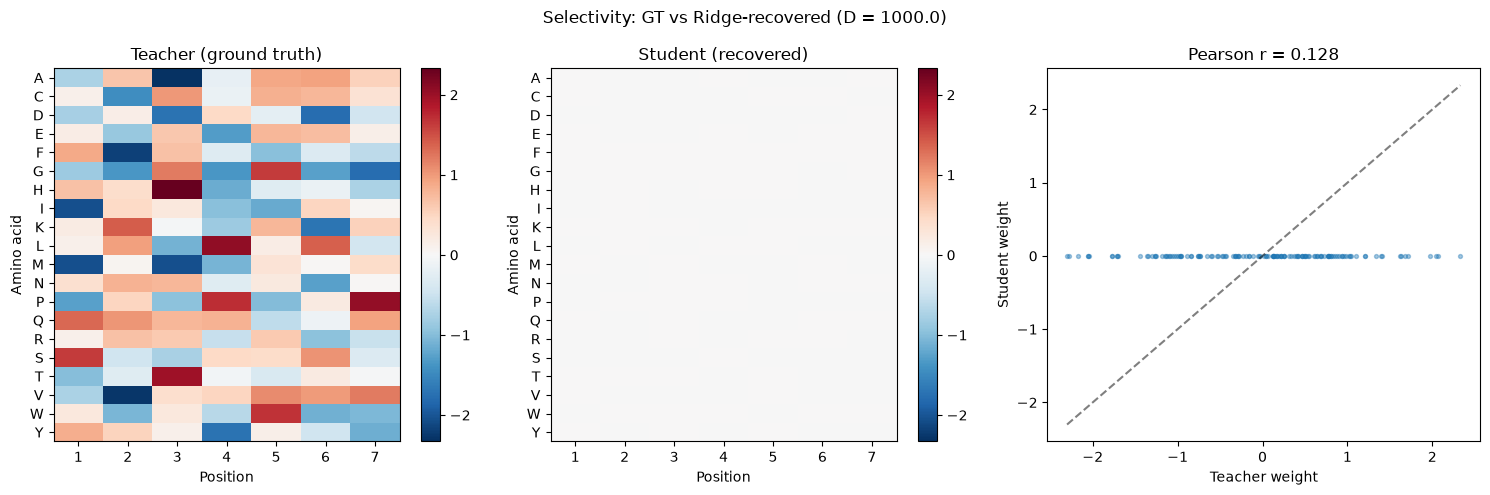

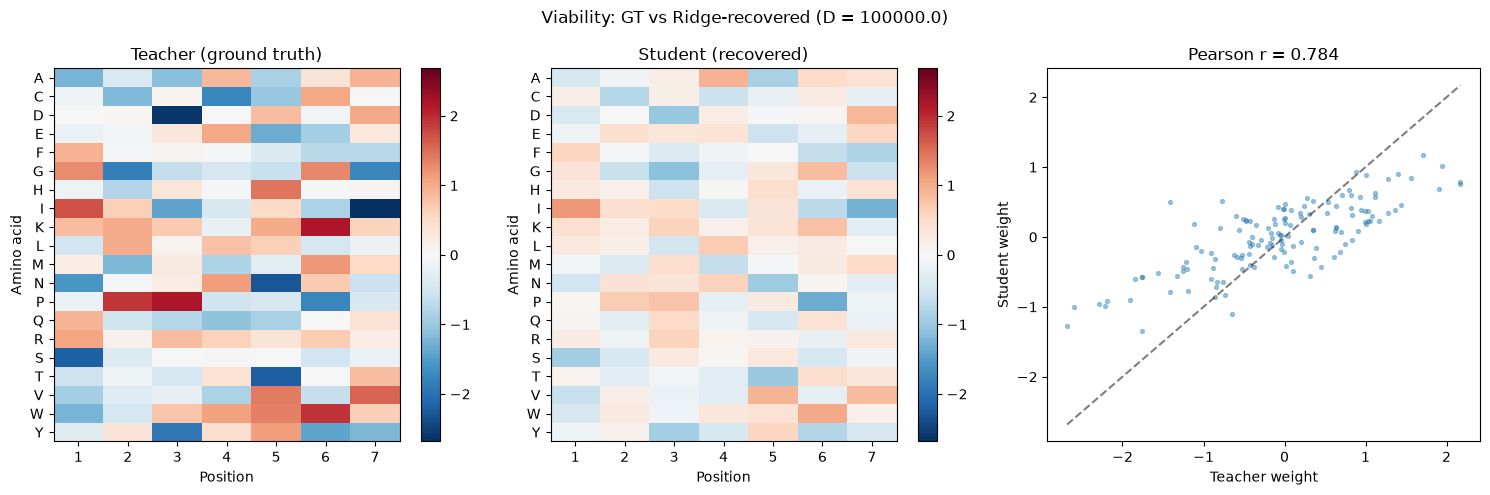

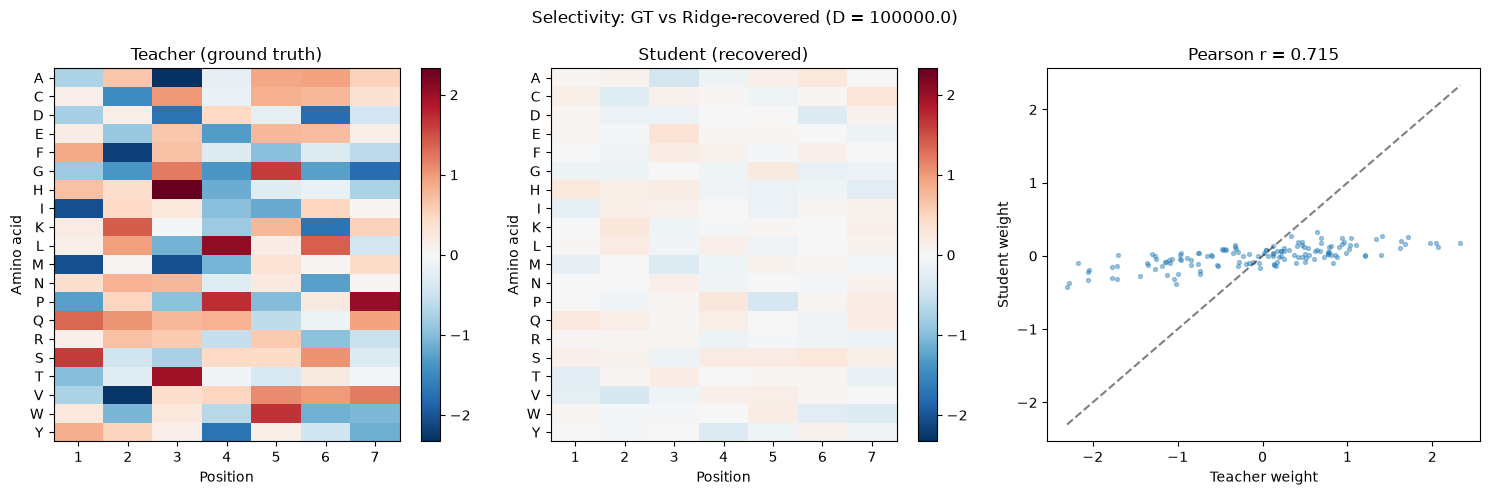

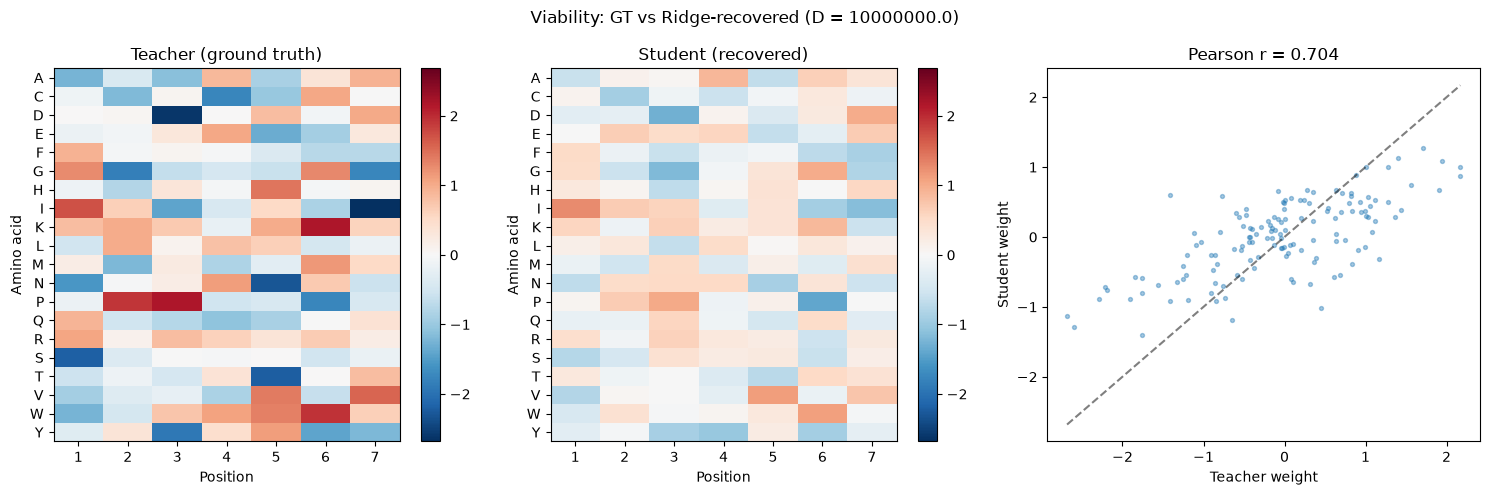

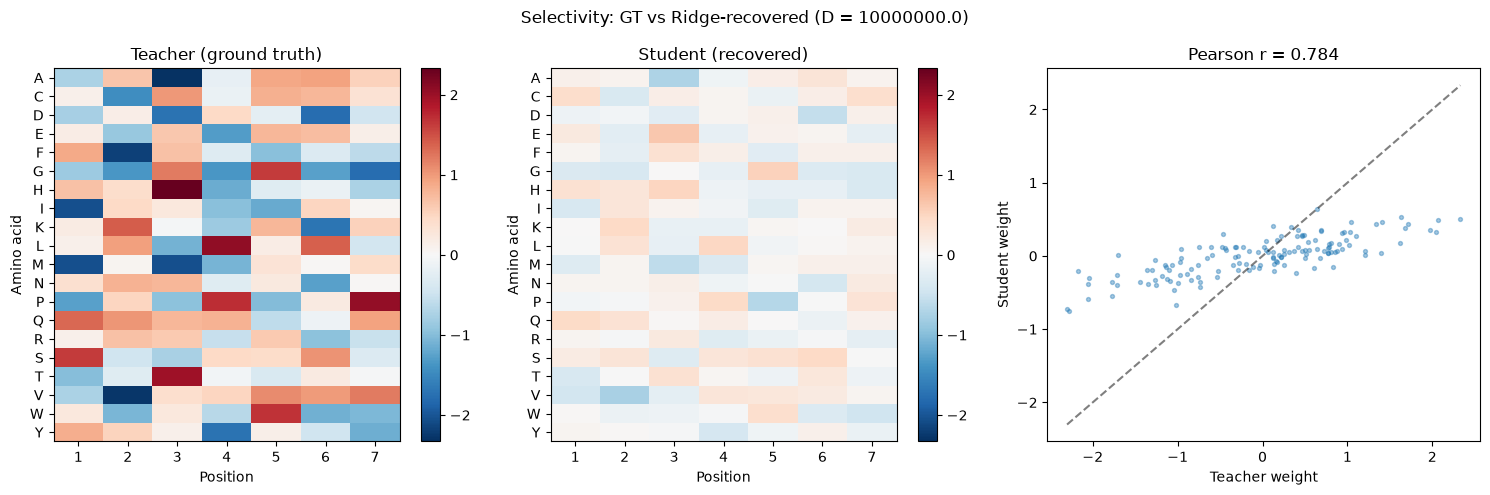

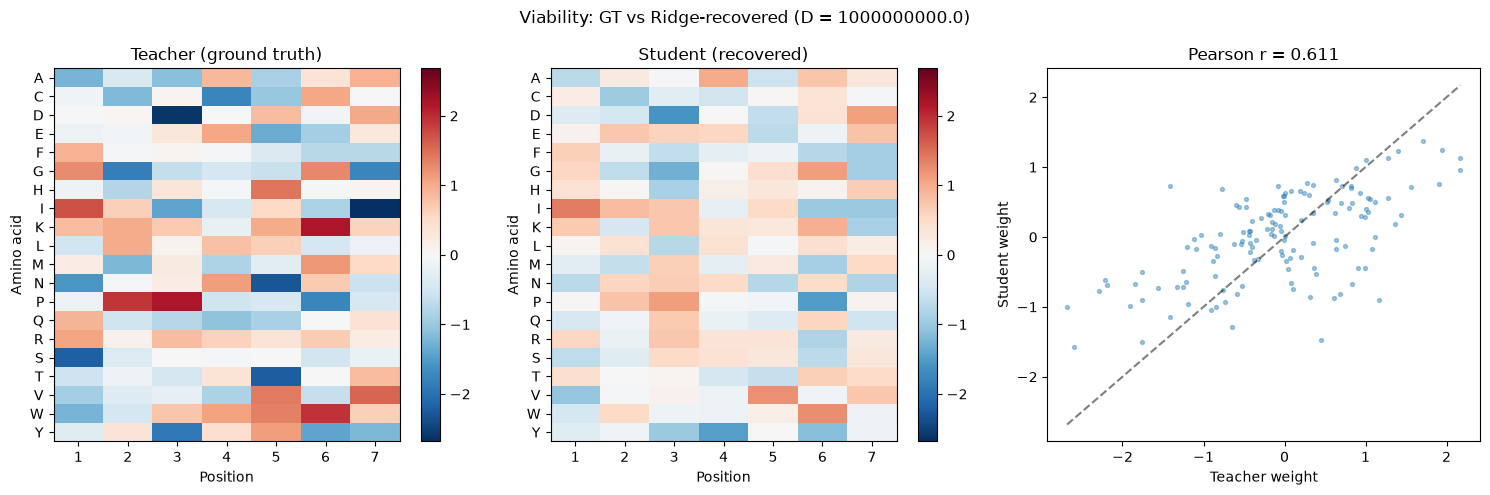

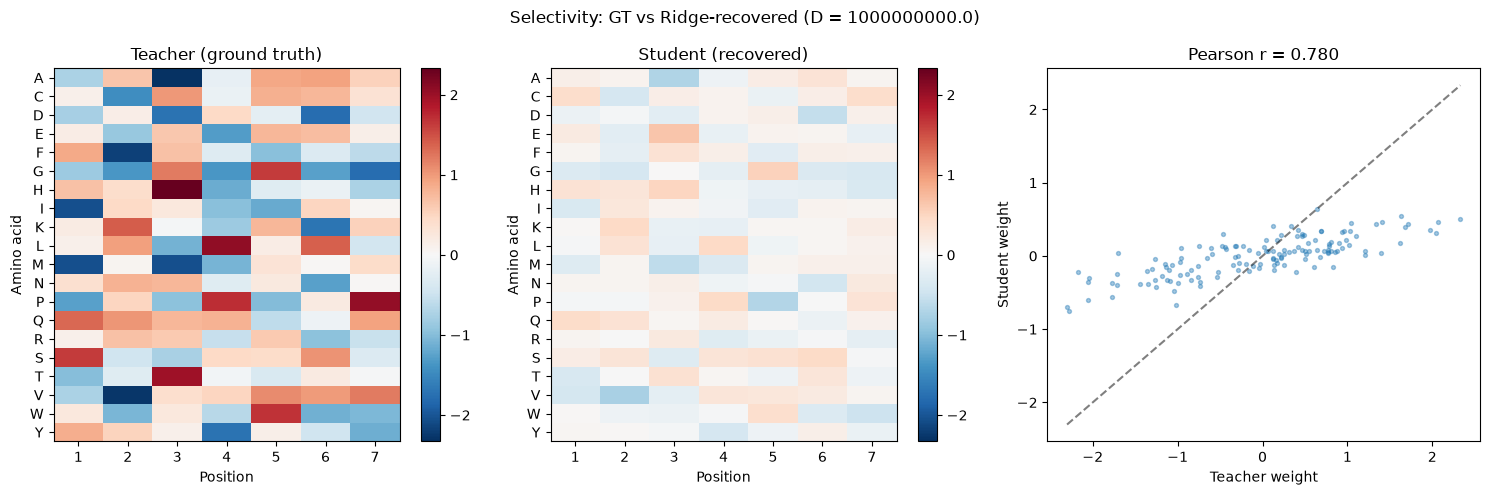

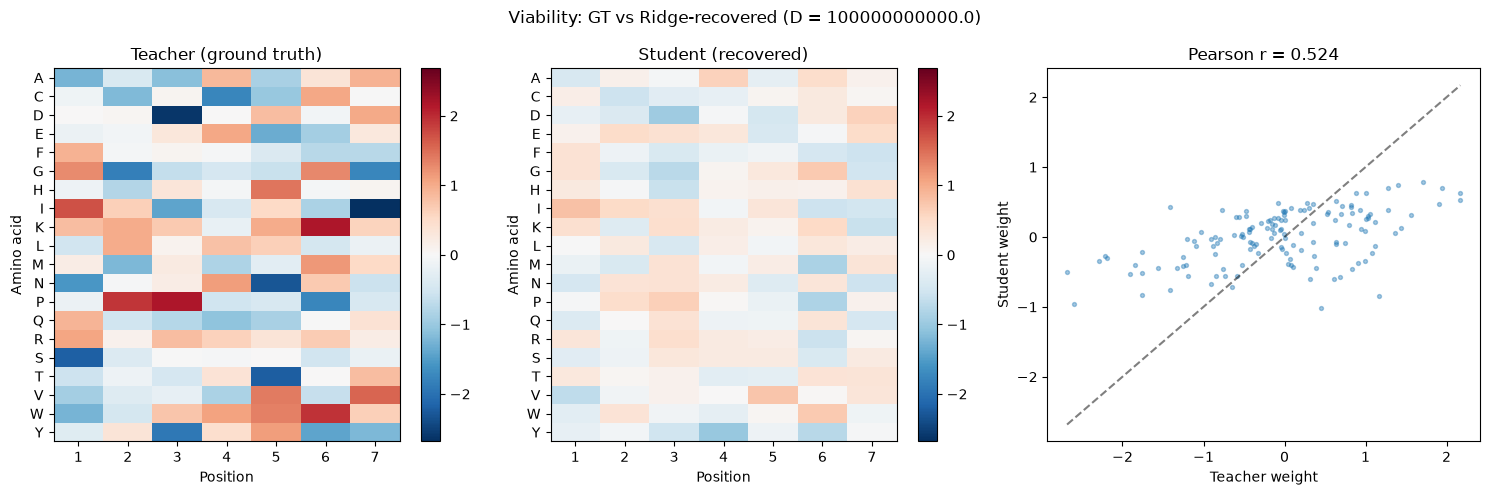

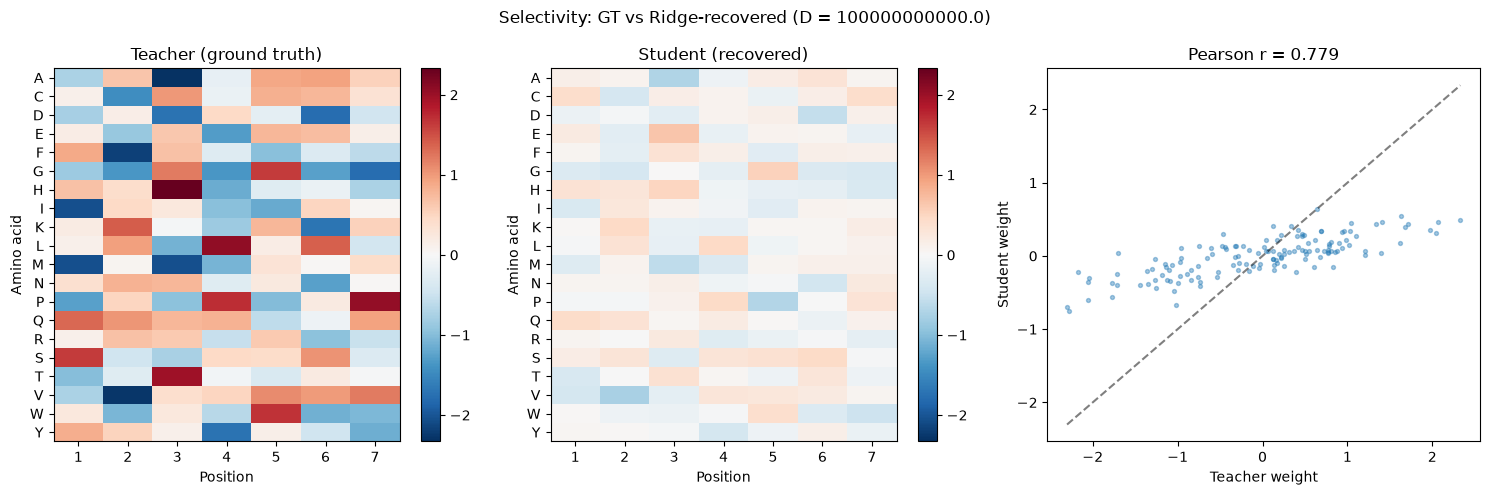

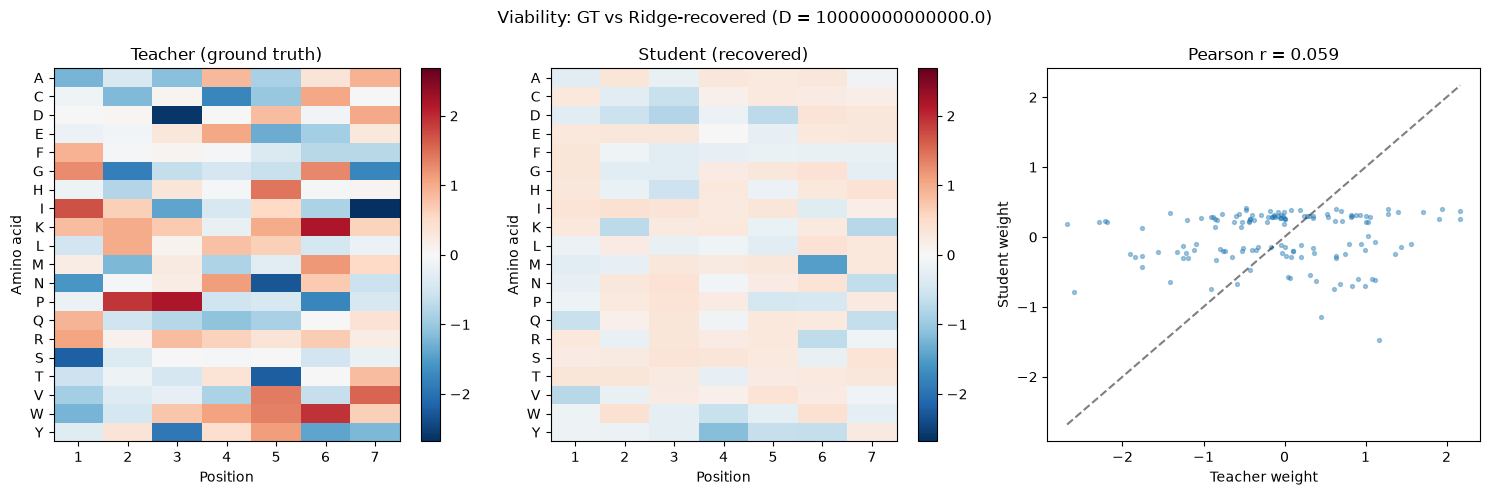

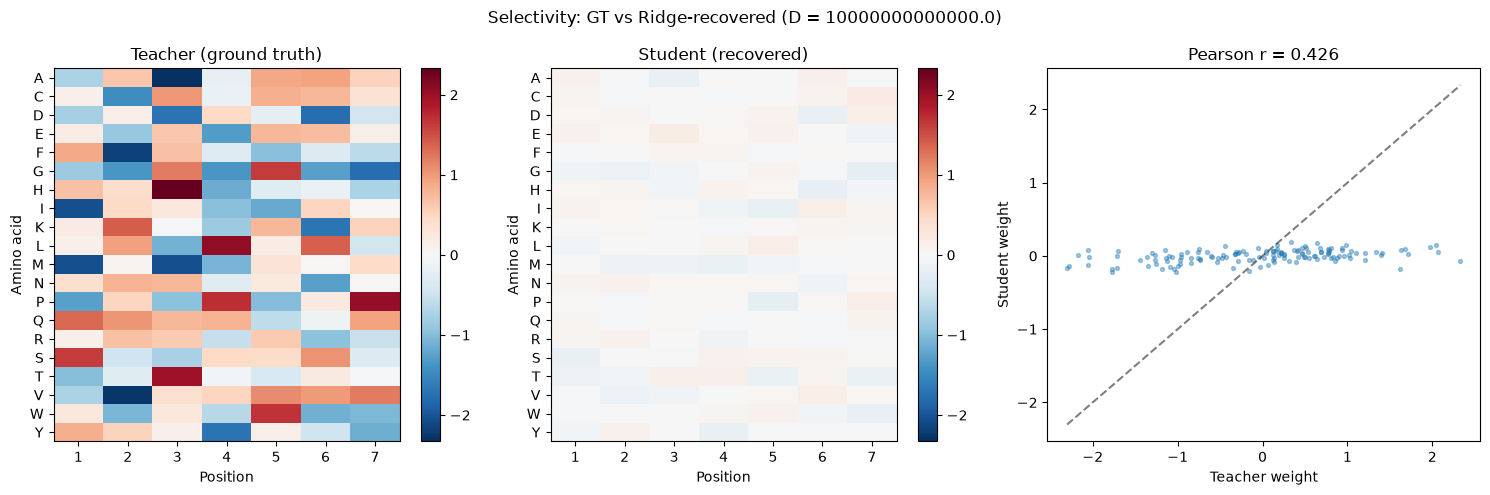

In [ ]:
key_reg_depth = jax.random.key(123)
key_reg_depth, k_seq_reg_depth = jax.random.split(key_reg_depth)
N_reg_depth = 2000
sequences_reg_depth = jax.random.randint(k_seq_reg_depth, shape=(N_reg_depth, 7), minval=0, maxval=20)

D_values = [1e3, 1e5, 1e7, 1e9, 1e11, 1e13]

for D_test in D_values:
    key_reg_depth = jax.random.key(123)
    key_reg_depth, k_seq_reg_depth = jax.random.split(key_reg_depth)
    N_reg_depth = 2000
    sequences_reg_depth = jax.random.randint(k_seq_reg_depth, shape=(N_reg_depth, 7), minval=0, maxval=20)

    print(D_test)
    protocol_reg_depth = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_depth, D=D_test,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab, T_sel=new_T_sel
    )

    F_viab_hat_depth, J_viab_hat_depth, F_sel_hat_depth, J_sel_hat_depth, info_depth = reg.recover_weights_from_NGS(
        protocol_reg_depth, n_rounds=1, k_folds=3,
    )

    results_depth = reg.evaluate_recovery(protocol_reg_depth, F_viab_hat_depth, J_viab_hat_depth, F_sel_hat_depth, J_sel_hat_depth)
    print()
    print(f"n_obs_viab = {info_depth['n_obs_viab']}   n_obs_sel = {info_depth['n_obs_sel']}")
    print(f"best lambda (viab) = {info_depth['lam_viab']:.3f}   best lambda (sel) = {info_depth['lam_sel']:.3f}")
    print()
    for key, val in results_depth.items():
        print(f'  {key:20s} : {val:.4f}')
    _ = plot_teacher_vs_student(F_viab, F_viab_hat_depth, title=f"Viability: GT vs Ridge-recovered (D = {D_test})")
    _ = plot_teacher_vs_student(F_sel, F_sel_hat_depth, title=f"Selectivity: GT vs Ridge-recovered (D = {D_test})")
    print("########################################################################################################")
    print()

## 9 bis. Clean selectivity-pressure sweep -- controlled confounds, no rank degeneracy

Section 7's sweep had two issues that were confounding the "viability recovery should be
invariant to T_sel" comparison:

- **`sequences` was regenerated per situation from a fresh top-level key**, and the
  "pressure on sel" cell used `jax.random.key(12)` instead of `key(123)` like every
  sibling cell -- a typo that silently swapped in a *different* set of 2000 sequences,
  which the Ridge regression's design matrix and targets both depend on.
- **`N = 2000`** while the Potts feature matrix has
  `L*A + C(L,2)*A**2 + 1 = 7*20 + 21*400 + 1 = 8541` columns -- deep in `p >> n`
  territory, so the fit is essentially propped up by the ridge penalty alone
  (rank-deficient `X.T @ X`).

Below: **one** `sequences` array, generated once and reused for every `T_sel` value
(no regeneration, no key typo possible), `N = 20_000` so there are comfortably more
observations than features, and every viability-relevant parameter
(`N0, N1, D, dilution_factor, noise_viab, T_viab`) held fixed across the sweep so only
`T_sel` changes. This also keeps `fit_weights_potts`'s `F_hat = F_flat * T_viab`
rescale constant across situations, so `plot_teacher_vs_student`'s shared color scale
can't make recovery look worse/better than it is.

In [ ]:
key_clean = jax.random.key(123)
key_clean, k_seq_clean = jax.random.split(key_clean)
N_clean = 20_000
sequences_clean = jax.random.randint(k_seq_clean, shape=(N_clean, 7), minval=0, maxval=20)

n_features = 7 * 20 + (7 * 6 // 2) * 20 * 20 + 1
print(f"N = {N_clean} sequences  vs  {n_features} Potts features  (ratio = {N_clean / n_features:.2f}x, "
      f"section 7's sweep ran at {2000 / n_features:.2f}x)")

T_sel_values = [0.1, 0.5, 2.0, 10.0]

protocols_clean = {}
datasets_clean  = {}

for T_sel_test in T_sel_values:
    protocol = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_clean, D=100_000_000,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1, T_viab=0.5, T_sel=T_sel_test,
    )
    protocols_clean[T_sel_test] = protocol
    datasets_clean[T_sel_test]  = reg.build_multi_round_dataset(protocol, n_rounds=1)

# Sanity check: sequences/T_viab/noise_viab/N0/N1/D/dilution_factor are identical across
# every T_sel value above, so the viability dataset (built from lambda0p -> lambda2p,
# both computed before selectivty() ever runs) must come out bit-for-bit identical.
seqs_viab_ref, y_viab_ref, _, _ = datasets_clean[T_sel_values[0]]
print()
for T_sel_test in T_sel_values[1:]:
    seqs_viab_t, y_viab_t, _, _ = datasets_clean[T_sel_test]
    same_seqs = np.array_equal(seqs_viab_ref, seqs_viab_t)
    same_y    = np.array_equal(y_viab_ref, y_viab_t)
    print(f"T_sel={T_sel_test:>5}: seqs_viab identical to T_sel={T_sel_values[0]}? {same_seqs}   "
          f"y_viab identical? {same_y}")

N = 20000 sequences  vs  8541 Potts features  (ratio = 2.34x, section 7's sweep ran at 0.23x)


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.97it/s]
                                                           


T_sel=  0.5: seqs_viab identical to T_sel=0.1? True   y_viab identical? True
T_sel=  2.0: seqs_viab identical to T_sel=0.1? True   y_viab identical? True
T_sel= 10.0: seqs_viab identical to T_sel=0.1? True   y_viab identical? True


### T_sel = 0.1  (T_viab fixed at 0.5, N = 20000) ###
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  1.94it/s]


Viability   dataset: 20000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 4630 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 31.6228
n_obs_viab = 20000   n_obs_sel = 4630
best lambda (viab) = 100.000   best lambda (sel) = 31.623
  r_viab_scores        : 0.8860
  r_sel_scores         : 0.7298
  r_viab_weights       : 0.9702
  r_sel_weights        : 0.7640
  precision_at_1pct    : 0.4150
  precision_at_10pct   : 0.6170
########################################################################################################

### T_sel = 0.5  (T_viab fixed at 0.5, N = 20000) ###
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.32it/s]


...

Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 31.6228
n_obs_viab = 20000   n_obs_sel = 4630
best lambda (viab) = 100.000   best lambda (sel) = 31.623
  r_viab_scores        : 0.8860
  r_sel_scores         : 0.8649
  r_viab_weights       : 0.9702
  r_sel_weights        : 0.9249
  precision_at_1pct    : 0.4800
  precision_at_10pct   : 0.7085
########################################################################################################

### T_sel = 10.0  (T_viab fixed at 0.5, N = 20000) ###
lambdas_grid was not defined thus lambdas_grid = [1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03 3.16227766e+03 1.00000000e+04 3.16227766e+04
 1.00000000e+05 3.16227766e+05 1.00000000e+06]
JAX backend: gpu -- devices: [CudaDevice(id=0)]


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.36it/s]


Viability   dataset: 20000 observed (sequence, round) pairs over 1 rounds
Selectivity dataset: 4630 observed (sequence, round) pairs over 1 rounds
Just finished building the Potts features


Best lambda (viability)   : 100.0000
Best lambda (selectivity) : 100.0000
n_obs_viab = 20000   n_obs_sel = 4630
best lambda (viab) = 100.000   best lambda (sel) = 100.000
  r_viab_scores        : 0.8860
  r_sel_scores         : 0.4105
  r_viab_weights       : 0.9702
  r_sel_weights        : 0.4662
  precision_at_1pct    : 0.4700
  precision_at_10pct   : 0.7000
########################################################################################################



,r_viab_scores,r_sel_scores,r_viab_weights,r_sel_weights,precision_at_1pct,precision_at_10pct,lam_viab,lam_sel,n_obs_viab,n_obs_sel
T_sel,,,,,,,,,,
0.1,0.886024,0.729768,0.970151,0.763983,0.415,0.6170,100.0,31.622777,20000,4630
0.5,0.886024,0.852080,0.970151,0.933336,0.420,0.6520,100.0,10.000000,20000,4630
2.0,0.886024,0.864892,0.970151,0.924912,0.480,0.7085,100.0,31.622777,20000,4630
10.0,0.886024,0.410542,0.970151,0.466166,0.470,0.7000,100.0,100.000000,20000,4630


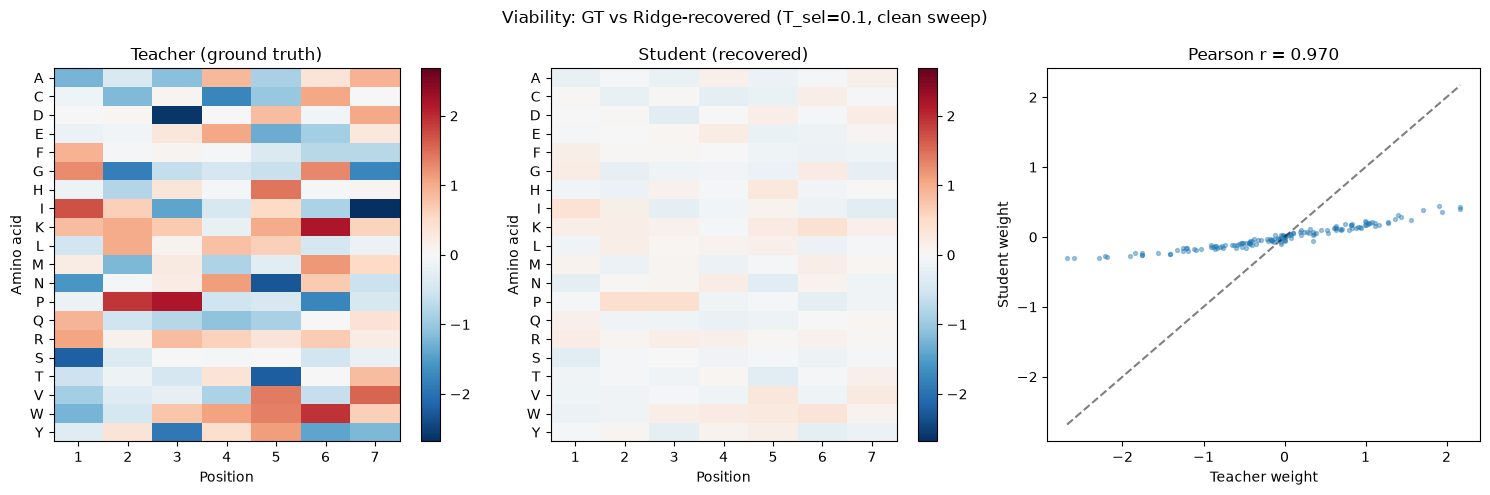

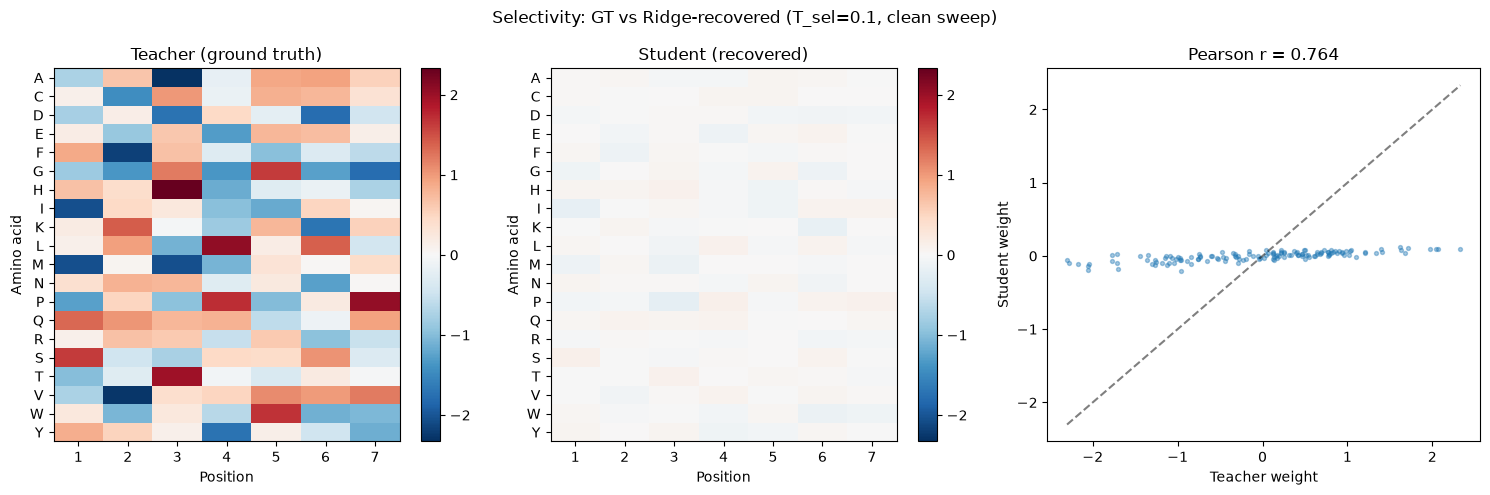

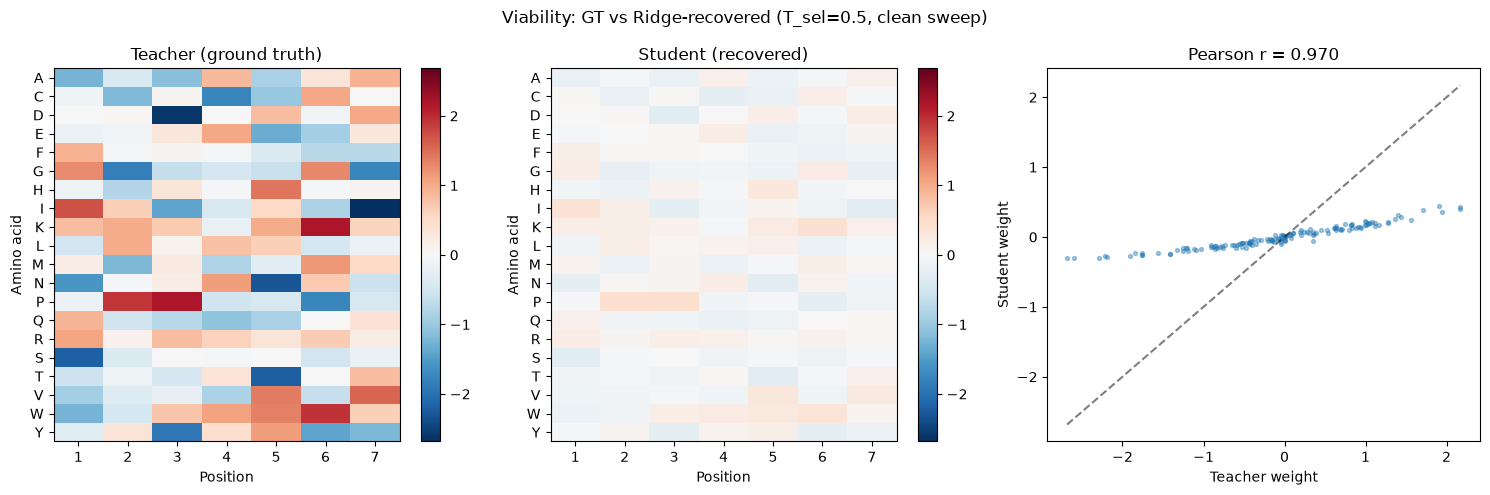

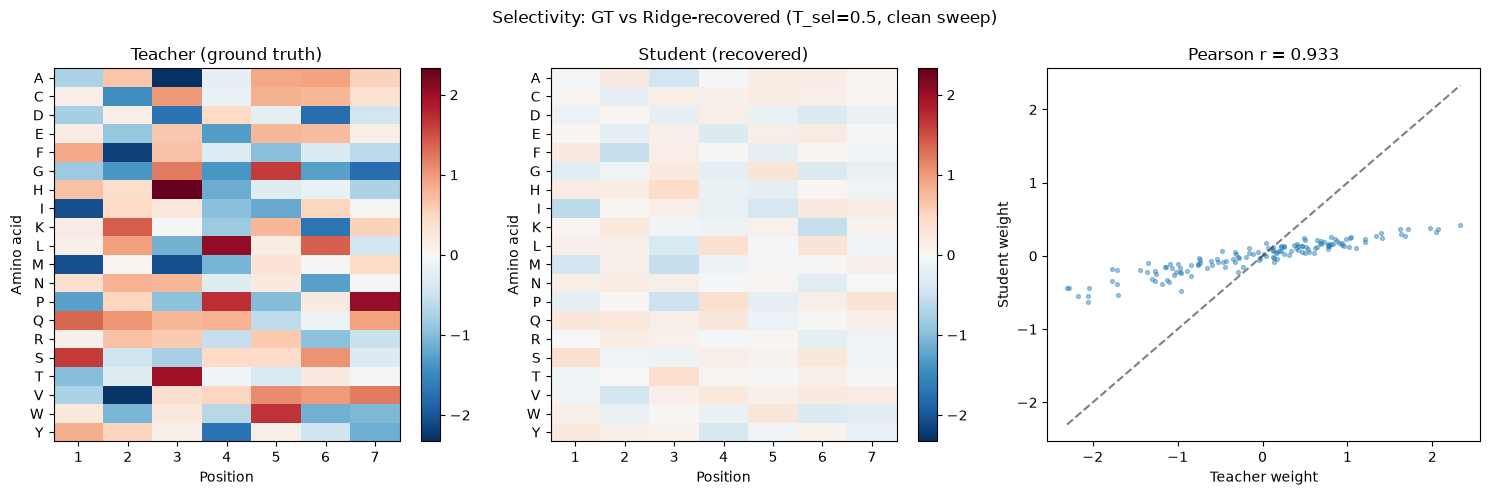

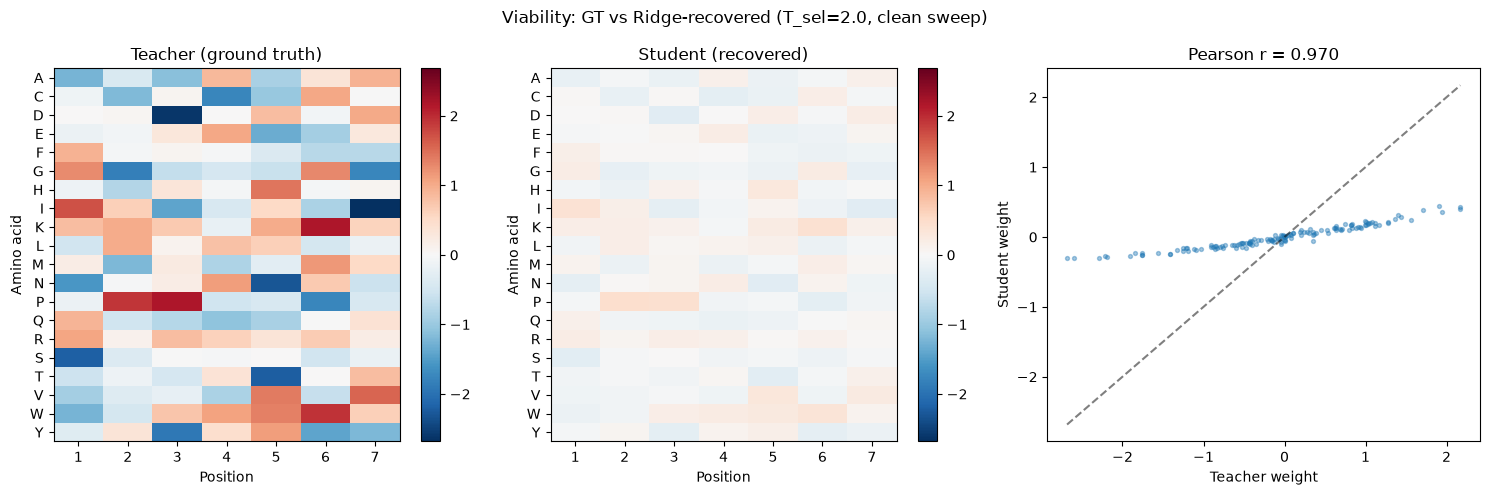

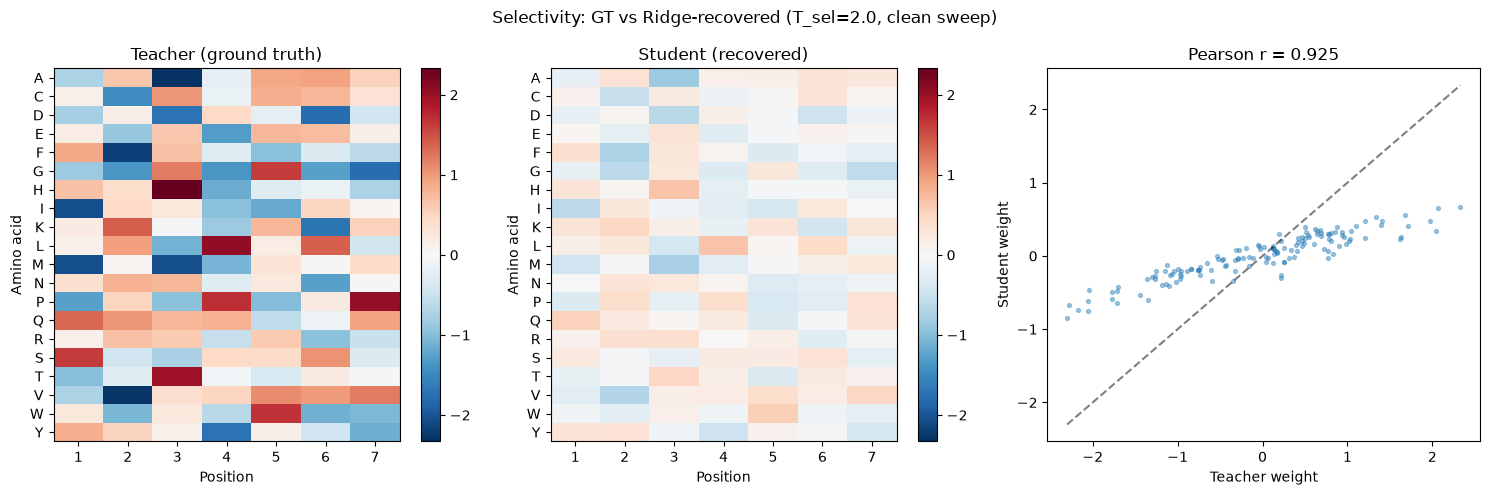

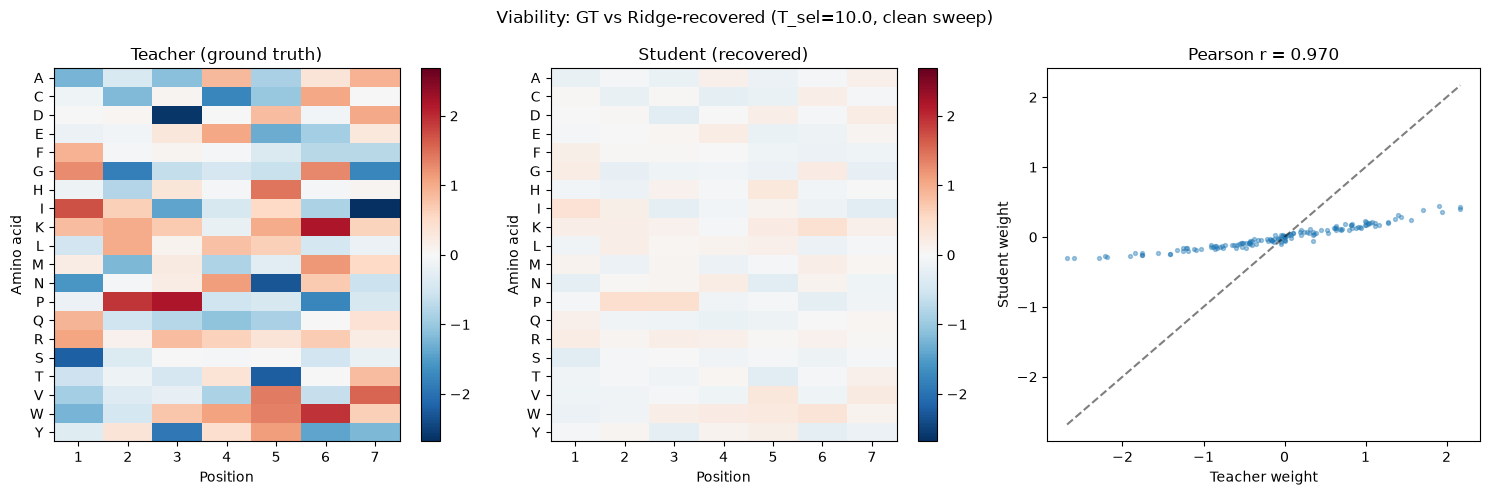

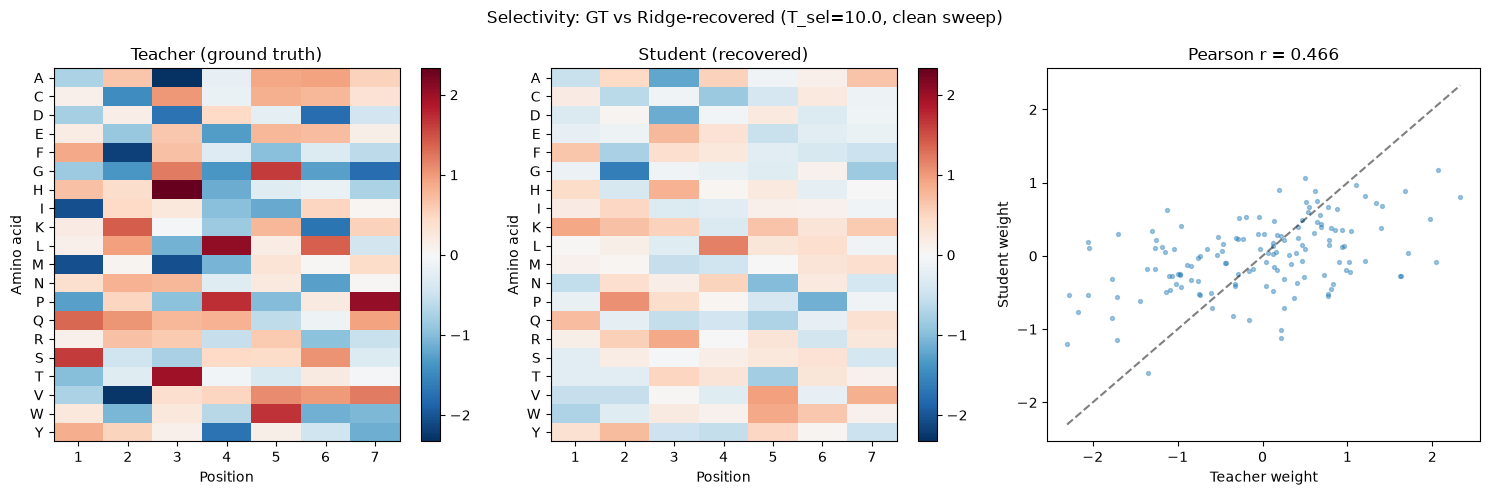

In [ ]:
results_clean_summary = []

for T_sel_test in T_sel_values:
    protocol = protocols_clean[T_sel_test]
    print(f"### T_sel = {T_sel_test}  (T_viab fixed at 0.5, N = {N_clean}) ###")

    F_viab_hat_c, J_viab_hat_c, F_sel_hat_c, J_sel_hat_c, info_c = reg.recover_weights_from_NGS(
        protocol, n_rounds=1, k_folds=3,
    )

    eval_c = reg.evaluate_recovery(protocol, F_viab_hat_c, J_viab_hat_c, F_sel_hat_c, J_sel_hat_c)
    print(f"n_obs_viab = {info_c['n_obs_viab']}   n_obs_sel = {info_c['n_obs_sel']}")
    print(f"best lambda (viab) = {info_c['lam_viab']:.3f}   best lambda (sel) = {info_c['lam_sel']:.3f}")
    for k, v in eval_c.items():
        print(f"  {k:20s} : {v:.4f}")

    _ = plot_teacher_vs_student(F_viab, F_viab_hat_c, title=f"Viability: GT vs Ridge-recovered (T_sel={T_sel_test}, clean sweep)")
    _ = plot_teacher_vs_student(F_sel,  F_sel_hat_c,  title=f"Selectivity: GT vs Ridge-recovered (T_sel={T_sel_test}, clean sweep)")

    eval_c["T_sel"]     = T_sel_test
    eval_c["lam_viab"]  = info_c["lam_viab"]
    eval_c["lam_sel"]   = info_c["lam_sel"]
    eval_c["n_obs_viab"] = info_c["n_obs_viab"]
    eval_c["n_obs_sel"]  = info_c["n_obs_sel"]
    results_clean_summary.append(eval_c)
    print("########################################################################################################")
    print()

results_clean_df = pd.DataFrame(results_clean_summary).set_index("T_sel")
results_clean_df

## 10. Let's try something with every parameters

In [ ]:
"""key_reg_all = jax.random.key(123)
key_reg_all, k_seq_reg_all = jax.random.split(key_reg_all)
N_reg_all = 10_000
sequences_reg_all = jax.random.randint(k_seq_reg_all, shape=(N_reg_all, 7), minval=0, maxval=20)

F_viab_hat_list, J_viab_hat_list, F_sel_hat_list, J_sel_hat_list, info_list = [], [], [], [], []

for i in range(N_split):
    protocol_reg_parallel = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_split[i], D=100_000_000,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1,
    )

    F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
        protocol_reg_parallel, n_rounds=1, k_folds=3,
    )
    F_viab_hat_list.append(F_viab_hat)
    J_viab_hat_list.append(J_viab_hat)
    F_sel_hat_list.append(F_sel_hat)
    J_sel_hat_list.append(J_sel_hat)
    info_list.append(info)

F_viab_hat_list = jnp.array(F_viab_hat_list)
J_viab_hat_list = jnp.array(J_viab_hat_list)
F_sel_hat_list  = jnp.array(F_sel_hat_list)
J_sel_hat_list  = jnp.array(J_sel_hat_list)

F_viab_hat_avg = jnp.mean(F_viab_hat_list, axis=0)
J_viab_hat_avg = jnp.mean(J_viab_hat_list, axis=0)
F_sel_hat_avg  = jnp.mean(F_sel_hat_list, axis=0)
J_sel_hat_avg  = jnp.mean(J_sel_hat_list, axis=0)

results_parallel = reg.evaluate_recovery(protocol_reg_parallel, F_viab_hat_avg, J_viab_hat_avg, F_sel_hat_avg, J_sel_hat_avg)

for i in range(N_split):
    print()
    print(f"n_obs_viab = {info_list[i]['n_obs_viab']}   n_obs_sel = {info_list[i]['n_obs_sel']}")
    print(f"best lambda (viab) = {info_list[i]['lam_viab']:.3f}   best lambda (sel) = {info_list[i]['lam_sel']:.3f}")

print()
for key, val in results_parallel.items():
    print(f'  {key:20s} : {val:.4f}')"""

## ??. Weights recovery : Impact of noise

We will do this part after finding which of the previous parameters are optimals.

# NEXT PART : Variants recovery

The question here is which value for the parameters is optimal to keep the best theoretical variants.